In [2]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [3]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    "text.usetex": True,        
    "font.family": "serif",     
    "font.serif": ["Times"],
    "figure.dpi": 300,          
    "axes.grid": True, 
    "grid.linestyle": "--",
    "grid.linewidth": 0.1,
    "grid.alpha": 0.05,
    "grid.linestyle": "--",     
})
from ps_utils import map2cl, get_lxly, cl2map
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2,fftshift
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d

In [4]:
RES = 256
STEP_SIZE = 6
ANG_X = 6.
ANG_Y = 6. 
flatskymapparams = [RES, RES, 60.*ANG_X/RES, 60.*ANG_X/RES] #Needs pixelres to be in arcmin
nx,ny,dx,dy = flatskymapparams
dx_rad = np.radians(dx/60.)
dy_rad = np.radians(dy/60.)
lx, ly = get_lxly(flatskymapparams)

ptsrc=2

In [5]:
lx=lx[0]
ly = ly[:,0]

# Loading and plotting

In [176]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz3.npy"

cib_maps = np.load(fpath_cib)  
tsz_maps = np.load(fpath_tsz) 

cut_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
cut_maps = cut_maps.transpose(0, 3, 1, 2)  


In [178]:
num_train = int(0.8 * num_samples)
rng = np.random.default_rng(seed=42)
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]
test_indices = indices[num_train:]
training_images = torch.tensor(cut_maps[train_indices], dtype=torch.float32)
testing_images = torch.tensor(cut_maps[test_indices], dtype=torch.float32)

In [179]:
print(np.min(cut_maps[train_indices][:,0]),np.max(cut_maps[train_indices][:,0]),np.mean(cut_maps[train_indices][:,0]))
print(np.min(cut_maps[test_indices][:,0]),np.max(cut_maps[test_indices][:,0]),np.mean(cut_maps[test_indices][:,0]))

0.0 110.732285 19.795584
0.0 103.85786 19.79652


In [180]:
print(np.min(cut_maps[train_indices][:,1]),np.max(cut_maps[train_indices][:,1]),np.mean(cut_maps[train_indices][:,1]))
print(np.min(cut_maps[test_indices][:,1]),np.max(cut_maps[test_indices][:,1]),np.mean(cut_maps[test_indices][:,1]))

-158.31772 0.0 -5.270609
-127.778366 0.0 -5.2694097


In [181]:
training_images = training_images.permute(0, 2, 3, 1)
testing_images = testing_images.permute(0, 2, 3, 1)

In [183]:
all_samples = np.load("data/low_pass/2mJy/new_samples_16_cib_tsz3_2mJy_zero_norm_6x6_w_au_lp.npy")

In [184]:
all_samples[:,0,] *= 110.732285
all_samples[:,0,] = ((all_samples[:,0,] - np.mean(all_samples[:,0,]))*(np.std(cut_maps[:,0,])/np.std(all_samples[:,0,]))) + np.mean(all_samples[:,0,])
all_samples[:,1,] *= 158.31772
all_samples[:,1,] -= 158.31772
all_samples[:,1,] = ((all_samples[:,1,] - np.mean(all_samples[:,1,]))*(np.std(cut_maps[:,1,])/np.std(all_samples[:,1,]))) + np.mean(all_samples[:,1,])

In [185]:
all_samples = all_samples.transpose(0, 2, 3, 1)

In [87]:
all_samples.shape

(960, 256, 256, 2)

In [88]:
np.min(cut_maps[:,0]),np.max(cut_maps[:,0]),np.mean(cut_maps[:,0]),np.std(cut_maps[:,0])

(np.float32(0.0),
 np.float32(110.732285),
 np.float32(19.795708),
 np.float32(5.793504))

In [186]:
np.min(all_samples[:,:,:,0]),np.max(all_samples[:,:,:,0]),np.mean(all_samples[:,:,:,0]),np.std(all_samples[:,:,:,0])

(np.float32(-0.6448765),
 np.float32(102.176735),
 np.float32(19.6852),
 np.float32(5.7935133))

In [18]:
np.min(cut_maps[:,1]),np.max(cut_maps[:,1]),np.mean(cut_maps[:,1]),np.std(cut_maps[:,1,])

(np.float32(-158.31772),
 np.float32(0.0),
 np.float32(-5.2703667),
 np.float32(2.8279552))

In [19]:
np.min(all_samples[:,1]),np.max(all_samples[:,1]),np.mean(all_samples[:,1]),np.std(all_samples[:,1,])

(np.float32(-80.48282),
 np.float32(70.0551),
 np.float32(7.0541687),
 np.float32(13.297214))

In [20]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_cib_joint3.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_tsz_joint3.npy"

cib_maps = np.load(fpath_cib)  # (N, H, W, 1)
tsz_maps = np.load(fpath_tsz)  # (N, H, W, 1)

gaussian_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
num_samples = len(gaussian_maps)

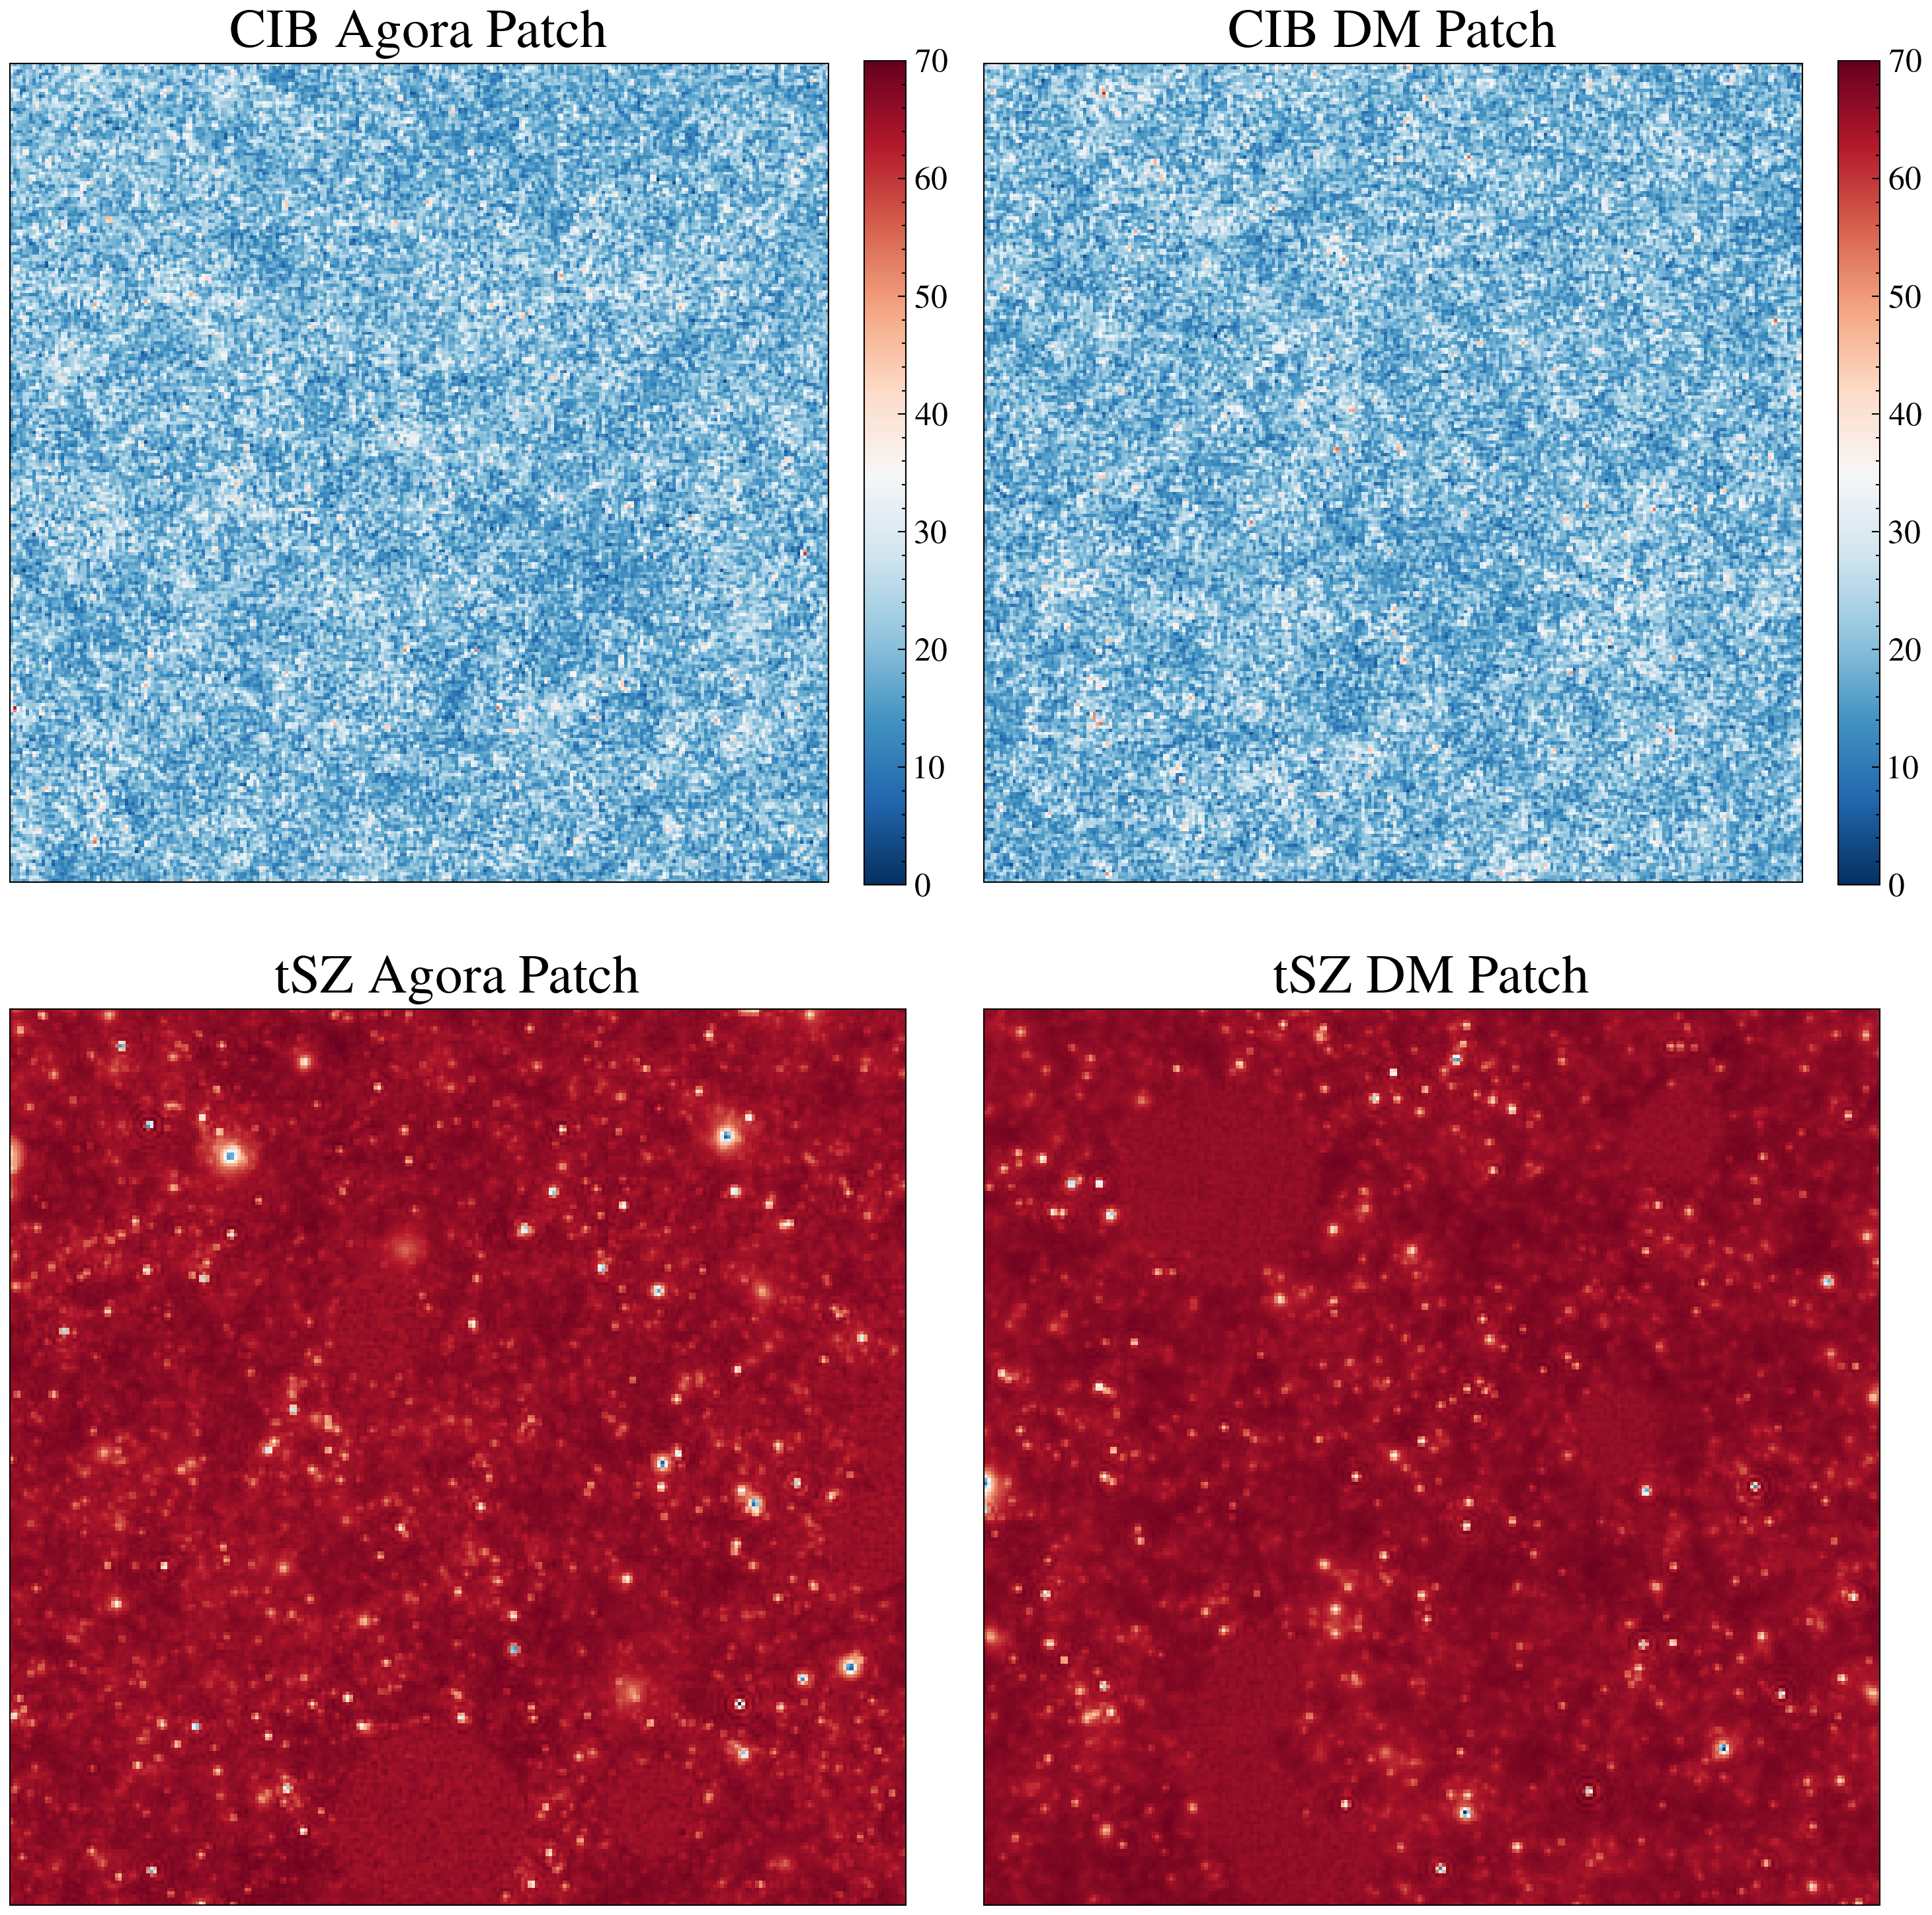

In [191]:
index=68
# --- CIB channel (0) ---
img_diff_cib = all_samples[index,:,:,0]
img_test_cib = training_images[index, :, :, 0].cpu().numpy()
#img_gaussian_cib = gaussian_maps[index][:,:,0]

# --- tSZ channel (1) ---
img_diff_tsz  = all_samples[index,:,:,1]
img_test_tsz = training_images[index, :, :, 1].cpu().numpy()
#img_gaussian_tsz = gaussian_maps[index][:,:,1]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
vmin_cib, vmax_cib = 0, 70
vmin_tsz, vmax_tsz = None, None
cmap_cib = 'RdBu_r'
cmap_tsz = 'RdBu_r'

# --- Plot CIB ---
im0 = axs[0, 0].imshow(img_test_cib, cmap=cmap_cib, vmin=vmin_cib, vmax=vmax_cib)
axs[0, 0].set_title("CIB Agora Patch", fontsize=20)
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

#im1 = axs[0, 1].imshow(img_gaussian_cib, cmap=cmap_cib, vmin=vmin_cib, vmax=vmax_cib)
#axs[0, 1].set_title("CIB Gaussian Patch", fontsize=16)
##fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

im2 = axs[0, 1].imshow(img_diff_cib, cmap=cmap_cib, vmin=vmin_cib, vmax=vmax_cib)
axs[0, 1].set_title("CIB DM Patch", fontsize=20)
fig.colorbar(im2, ax=axs[0, 1], fraction=0.046, pad=0.04)

# --- Plot tSZ ---
im3 = axs[1, 0].imshow(img_test_tsz, cmap=cmap_tsz, vmin=vmin_tsz, vmax=vmax_tsz)
axs[1, 0].set_title("tSZ Agora Patch", fontsize=20)
#fig.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)

#im4 = axs[1, 1].imshow(img_gaussian_tsz, cmap=cmap_tsz, vmin=vmin_tsz, vmax=vmax_tsz)
#axs[1, 1].set_title("tSZ Gaussian Patch", fontsize=16)
#fig.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)

im5 = axs[1, 1].imshow(img_diff_tsz, cmap=cmap_tsz, vmin=vmin_tsz, vmax=vmax_tsz)
axs[1, 1].set_title("tSZ DM Patch", fontsize=20)
#fig.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

# Cleanup
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_xlabel("x", fontsize=16)
    #ax.set_ylabel("y", fontsize=16)

plt.tight_layout()
#plt.subplots_adjust(wspace=0.05,)
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/examples.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/examples.png", dpi=200, bbox_inches="tight")
plt.show()

In [37]:
which_fg_model = 'agora'

fname = 'ilc_weights_residuals_%s_fg_model.npy' %(which_fg_model)
ilc_dict = np.load(fname, allow_pickle = True).item()
print(ilc_dict.keys())

#total ILC residuals
total_ilc_residuals_dict = ilc_dict['total_ilc_residuals']
print(total_ilc_residuals_dict.keys())

dict_keys(['weights', 'total_ilc_residuals', 'cib_plus_tsz_residuals', 'cib_residuals', 'tsz_residuals', 'noise_residuals', 'radio_residuals', 'nl_TP_dict', 'cl_signal_plus_noise', 'ilc_keyname_arr', 'el'])
dict_keys(['s4_wide', 's4_deep', 'spt3g', 'spt4', 'so_baseline', 'so_goal'])


In [38]:
l, nl_s4_wide = total_ilc_residuals_dict['s4_wide']['mv']
l, nl_s4_deep = total_ilc_residuals_dict['s4_deep']['mv']
l, nl_spt3g = total_ilc_residuals_dict['spt3g']['mv']

In [89]:
def compute_cls(images, channel1, channel2=None, n_samples=200, add_noise=False):
    cls = []
    for i in range(n_samples):
        map_1 = images[i, :, :, channel1].cpu().numpy() if hasattr(images[i], 'cpu') else images[i, :, :, channel1]
        map_2 = None
        if channel2 is not None:
            map_2 = images[i, :, :, channel2].cpu().numpy() if hasattr(images[i], 'cpu') else images[i, :, :, channel2]

        if add_noise:
            noise_map = cl2map(flatskymapparams, nl_spt3g, l)
            map_1 = np.copy(map_1) + noise_map
            if map_2 is not None:
                map_2 = np.copy(map_2) + noise_map

        ell, cl = map2cl(flatskymapparams, map_1, map_2)
        cls.append(cl)
    return np.array(cls), ell

In [90]:
cls_test_cib_clean, el = compute_cls(testing_images[:200], channel1=0, n_samples=200, add_noise=False)
cls_test_tsz_clean, _  = compute_cls(testing_images[:200], channel1=1, n_samples=200, add_noise=False)
cls_dm_cib_clean, _    = compute_cls(all_samples[:200], channel1=0, n_samples=200, add_noise=False)
cls_dm_tsz_clean, _    = compute_cls(all_samples[:200], channel1=1, n_samples=200, add_noise=False)

# Noisy for interval (with noise)
cls_test_cib_noisy, _ = compute_cls(testing_images[:200], channel1=0, n_samples=200, add_noise=True)
cls_test_tsz_noisy, _ = compute_cls(testing_images[:200], channel1=1, n_samples=200, add_noise=True)
cls_dm_cib_noisy, _   = compute_cls(all_samples[:200], channel1=0, n_samples=200, add_noise=True)
cls_dm_tsz_noisy, _   = compute_cls(all_samples[:200], channel1=1, n_samples=200, add_noise=True)

In [156]:
dl_factor = el * (el + 1) / (2 * np.pi)

mean_test_cib = dl_factor * np.mean(cls_test_cib_clean, axis=0)
mean_test_tsz = dl_factor * np.mean(cls_test_tsz_clean, axis=0)

mean_dm_cib = dl_factor * np.mean(cls_dm_cib_clean, axis=0)
mean_dm_tsz = dl_factor * np.mean(cls_dm_tsz_clean, axis=0)

std_test_cib = dl_factor * np.std(cls_test_cib_noisy, axis=0)
std_test_tsz = dl_factor * np.std(cls_test_tsz_noisy, axis=0)


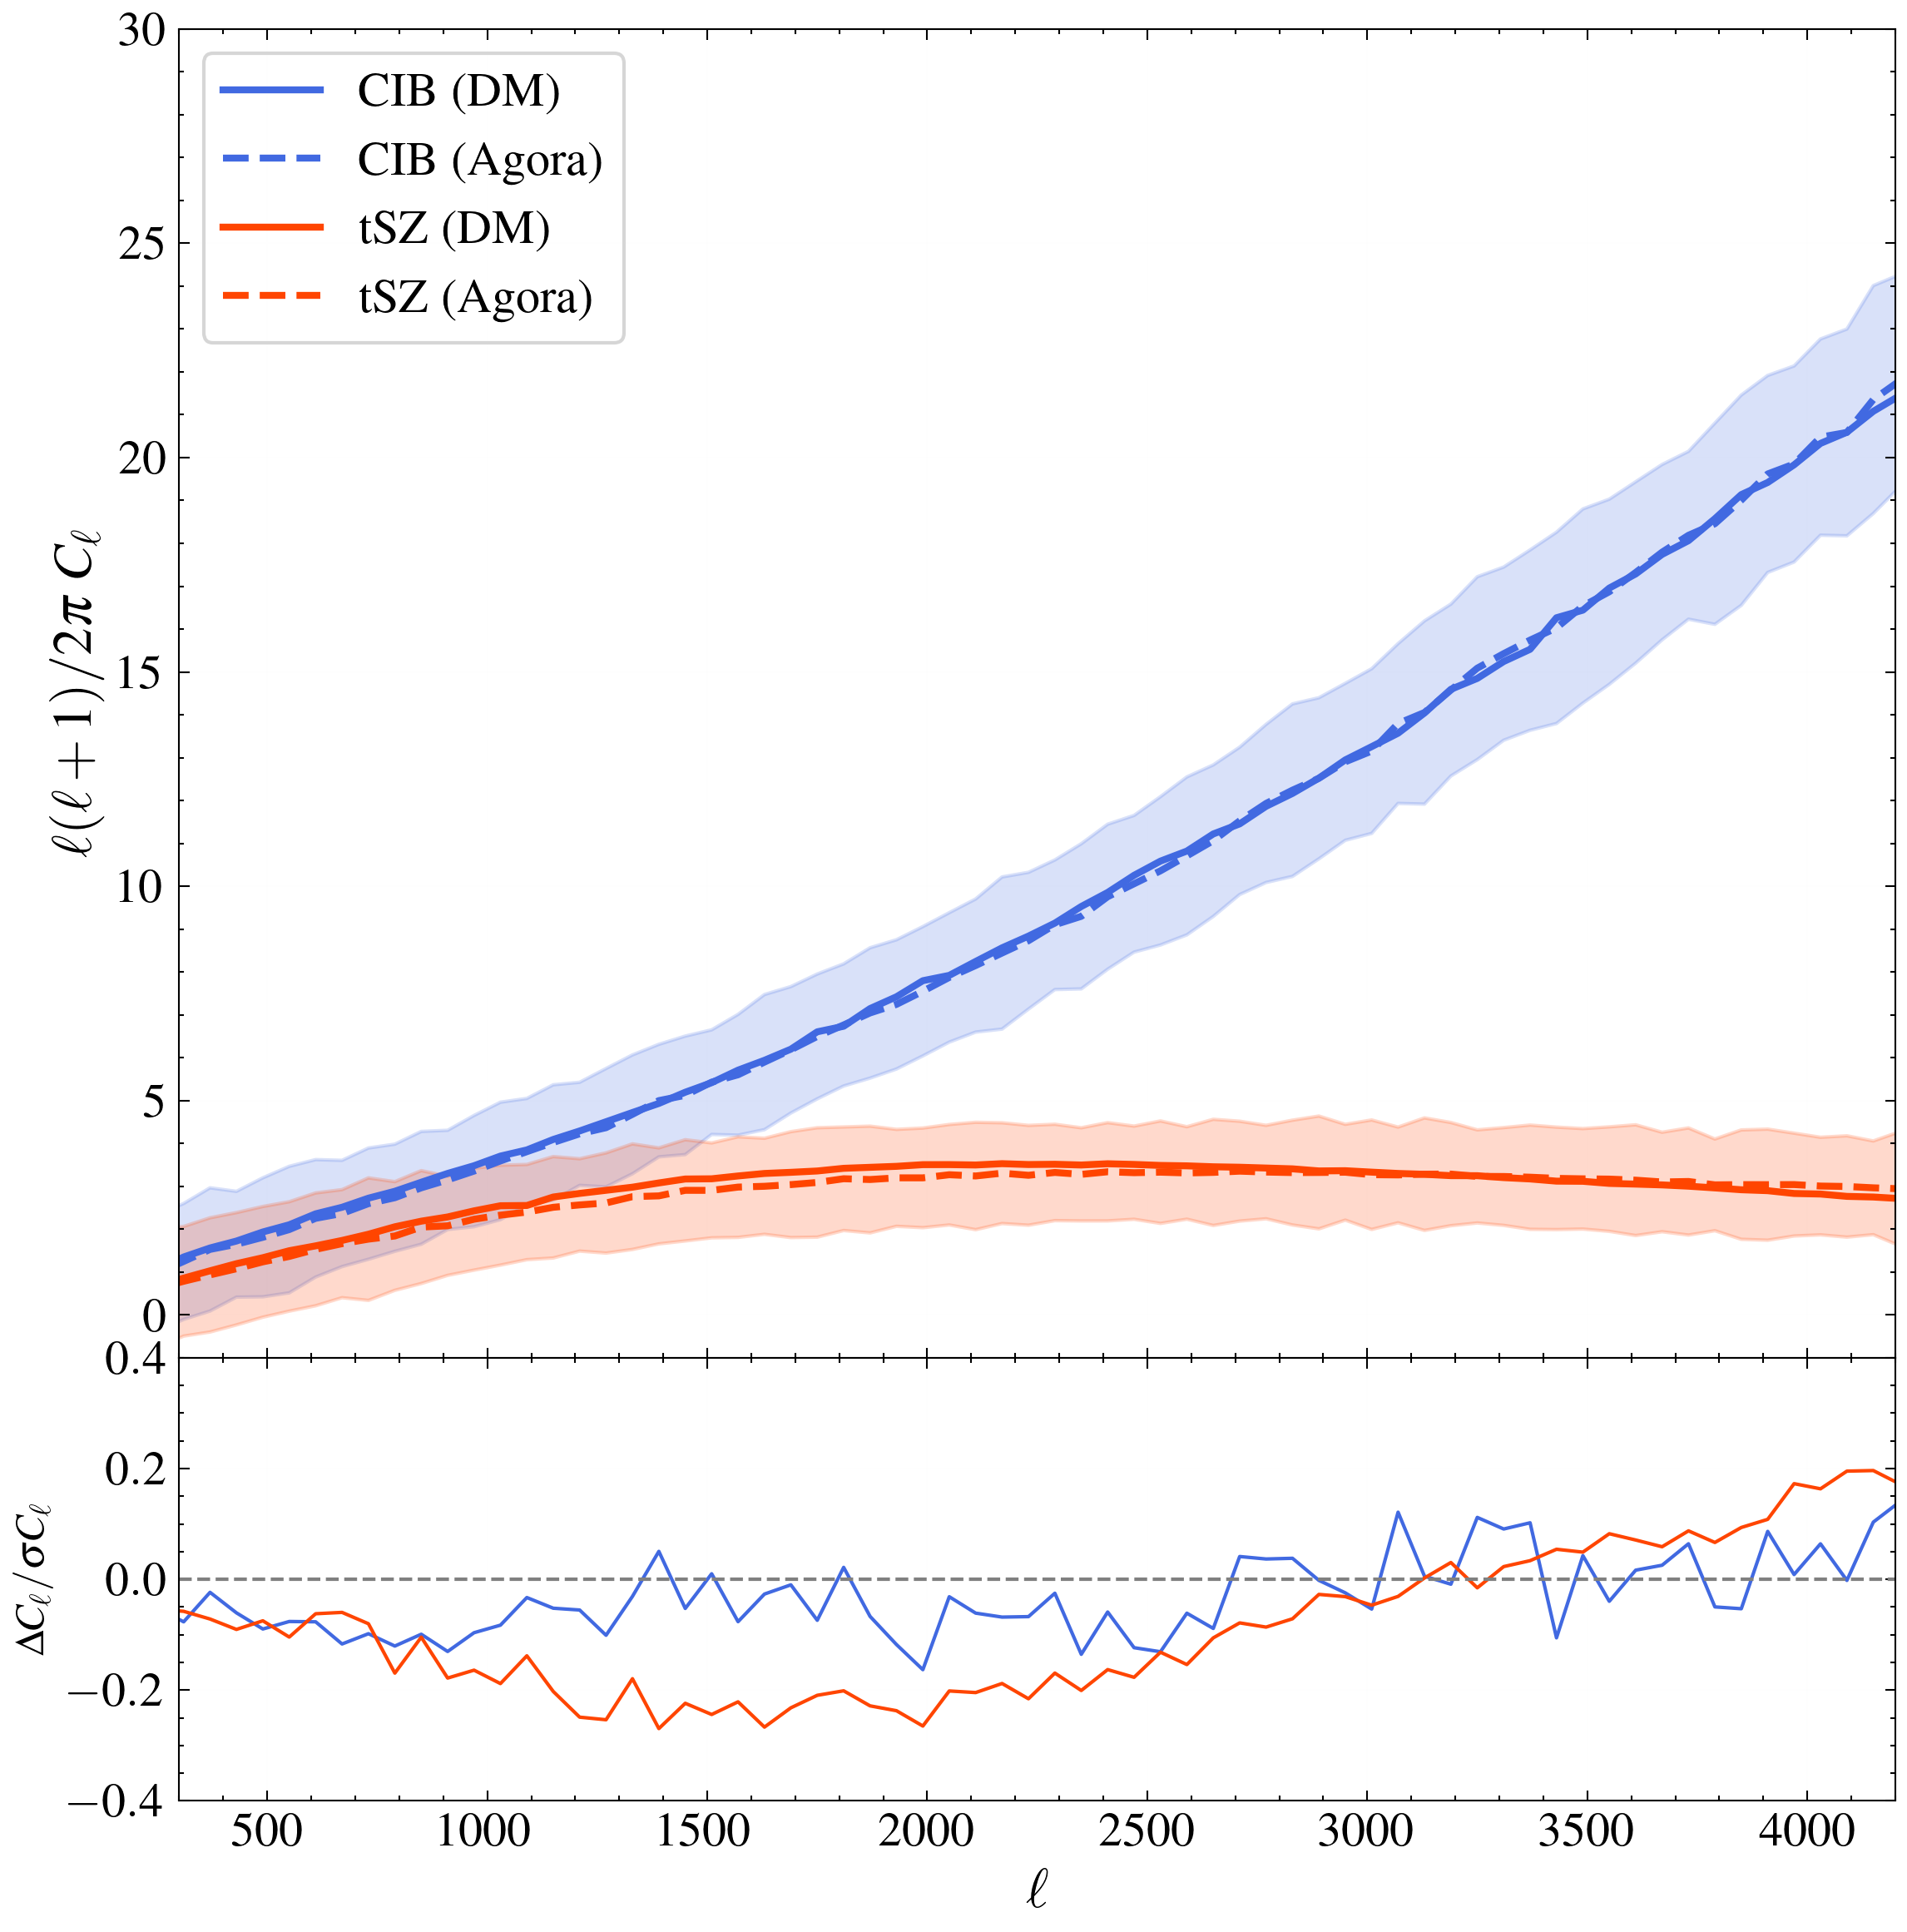

In [157]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)
#fig.suptitle("CIB and tSZ Power Spectra", fontsize=20)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

colors = {'CIB': 'royalblue', 'tSZ': 'orangered'}
ax1.fill_between(el, mean_test_cib - std_test_cib,
    mean_test_cib + std_test_cib, color=colors['CIB'], alpha=0.2)
ax1.plot(el, mean_dm_cib, color=colors['CIB'], lw=2, label="CIB (DM)")
ax1.plot(el, mean_test_cib, color=colors['CIB'], lw=2, ls='--', label="CIB (Agora)")


ax1.fill_between(el, mean_test_tsz - std_test_tsz,
    mean_test_tsz + std_test_tsz, color=colors['tSZ'], alpha=0.2)
ax1.plot(el, mean_dm_tsz, color=colors['tSZ'], lw=2, label="tSZ (DM)")
ax1.plot(el, mean_test_tsz, color=colors['tSZ'], lw=2, ls='--', label="tSZ (Agora)")

#ax1.set_yscale('log')
ax1.set_xlim(300, 4200)
#ax1.set_ylim(5e-7, 2e-4)
ax1.set_ylim(-1, 30)
ax1.set_ylabel(r"$\ell(\ell+1)/2\pi\ C_\ell$", fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=14, frameon=True, loc='upper left')
plt.setp(ax1.get_xticklabels(), visible=False)

# Bias
bias_cib = (mean_test_cib - mean_dm_cib) / std_dm_cib
bias_tsz = (mean_test_tsz - mean_dm_tsz) / std_dm_tsz

ax2.plot(el, bias_cib, color=colors['CIB'], lw=1, label="CIB Bias")
ax2.plot(el, bias_tsz, color=colors['tSZ'],lw=1, label="tSZ Bias")
ax2.axhline(0, color='gray', lw=1, ls='--')

ax2.set_xlabel(r"$\ell$", fontsize=16)
ax2.set_ylabel(r"$\Delta C_\ell / \sigma C_\ell$", fontsize=12)
ax2.set_ylim(-0.4, 0.4)
ax2.tick_params(axis='both', labelsize=14)
#ax2.legend(fontsize=14, frameon=True, loc='upper left')

plt.tight_layout()
#plt.savefig("figures/power_spectra_comparison_cib_tsz.png", dpi=200, bbox_inches="tight")
#plt.savefig("figures/power_spectra_comparison_cib_tsz.pdf", dpi=200, bbox_inches="tight")
plt.show()


In [121]:
cls_test_cross_clean, _ = compute_cls(testing_images[:200], channel1=0, channel2=1, n_samples=200, add_noise=False)
cls_dm_cross_clean, _   = compute_cls(all_samples[:200], channel1=0, channel2=1, n_samples=200, add_noise=False)

cls_test_cross_noisy, _ = compute_cls(testing_images[:200], channel1=0, channel2=1, n_samples=200, add_noise=True)
cls_dm_cross_noisy, _   = compute_cls(all_samples[:200], channel1=0, channel2=1, n_samples=200, add_noise=True)

/global/u2/k/kp22/ddpm_paper/ps_utils.py:254: ComplexWarning: Casting complex values to real discards the imaginary part
  radprf[b,1]=np.sum(z[ind])/hits


In [122]:
dl_test_cross = -1*dl_factor * cls_test_cross_clean
dl_dm_cross = -1* dl_factor * cls_dm_cross_clean
std_test_cross = dl_factor * np.std((-1*cls_test_cross_noisy), axis=0)

mean_dm_cross = np.mean(dl_dm_cross, axis=0)
mean_test_cross = np.mean(dl_test_cross, axis=0)
bias_cross = (mean_test_cross - mean_dm_cross) / std_dm_cross

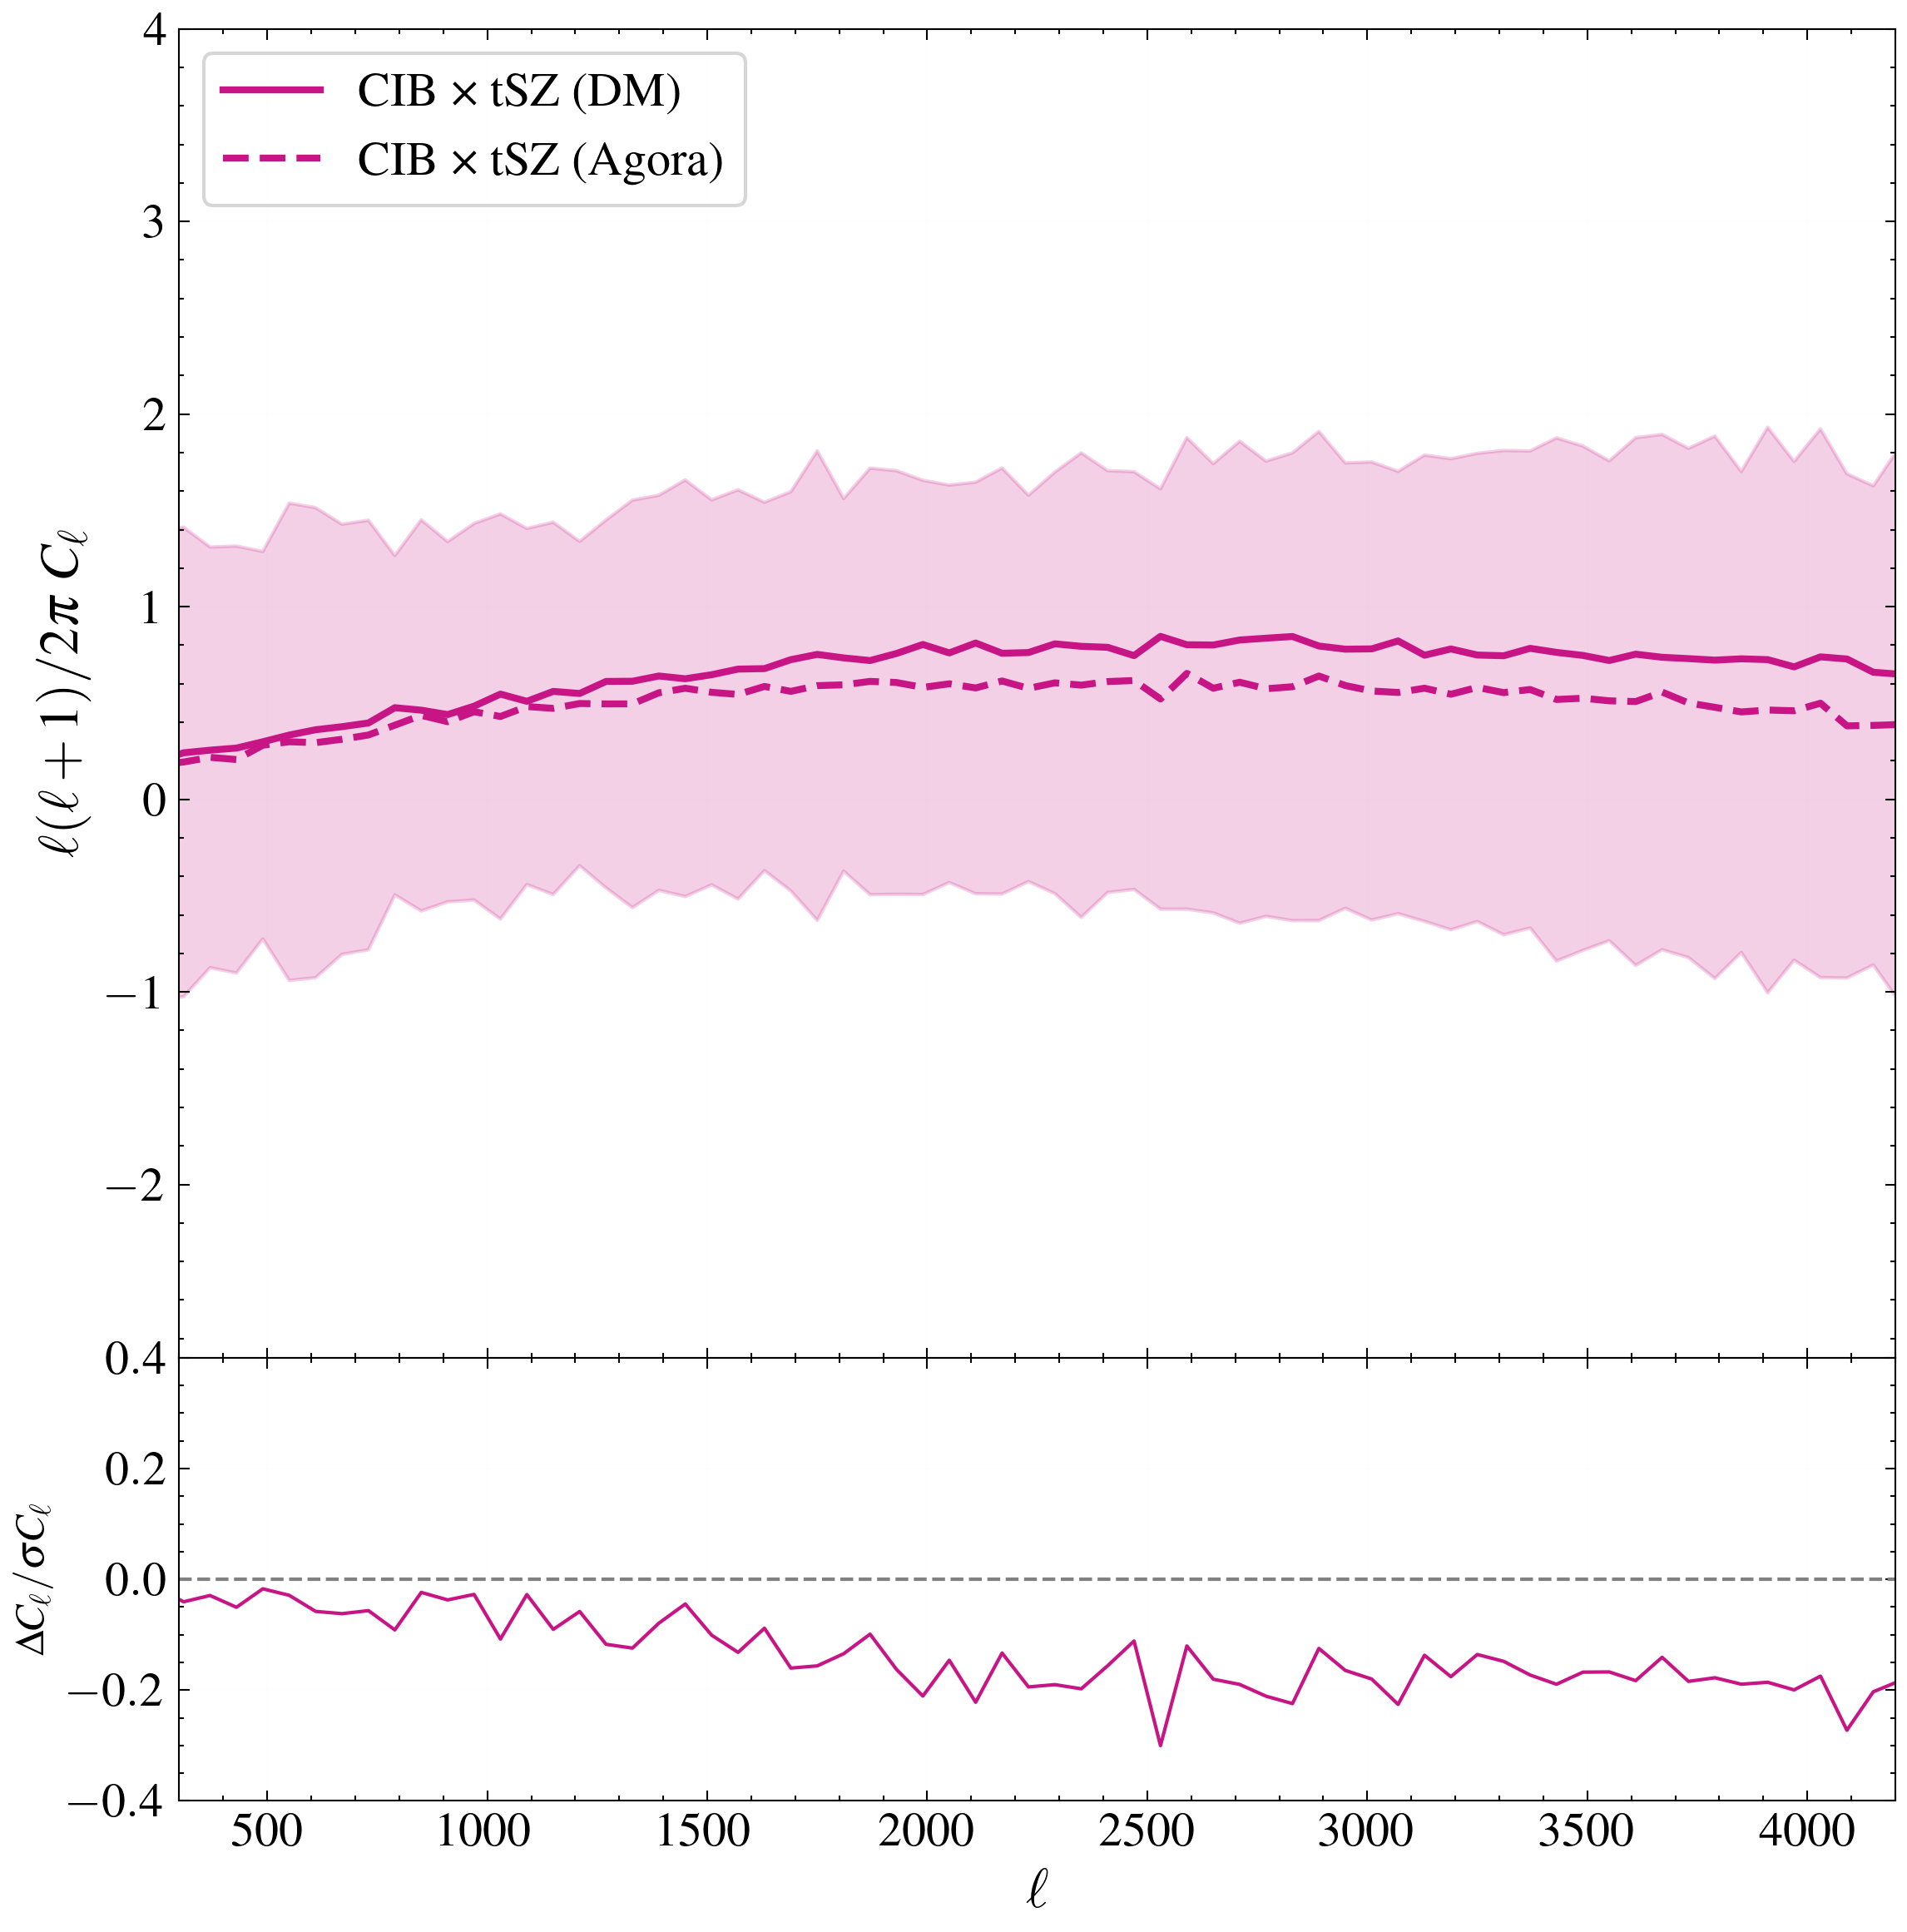

In [147]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# DM band with std deviation
ax1.fill_between(el, mean_test_cross - std_test_cross, mean_test_cross + std_test_cross,
                 color='mediumvioletred', alpha=0.2)

ax1.plot(el, abs(mean_dm_cross), color='mediumvioletred', lw=2, label="CIB × tSZ (DM)")
ax1.plot(el, abs(mean_test_cross), color='mediumvioletred', lw=2, ls='--', label="CIB × tSZ (Agora)")

#ax1.set_yscale('log')
ax1.set_xlim(300, 4200)
ax1.set_ylim(-2.9, 4)
ax1.set_ylabel(r"$\ell(\ell+1)/2\pi\ C_\ell$", fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.legend(fontsize=14, frameon=True, loc='upper left')
plt.setp(ax1.get_xticklabels(), visible=False)

# Bias plot
ax2.plot(el, bias_cross, color='mediumvioletred', lw=1)
ax2.axhline(0, color='gray', lw=1, ls='--')
ax2.set_xlabel(r"$\ell$", fontsize=16)
ax2.set_ylabel(r"$\Delta C_\ell / \sigma C_\ell$", fontsize=12)
ax2.set_ylim(-0.4, 0.4)
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig("figures/power_spectra_comparison_cib_tsz_cross.png", dpi=200, bbox_inches="tight")
plt.savefig("figures/power_spectra_comparison_cib_tsz_cross.pdf", dpi=200, bbox_inches="tight")
plt.show()

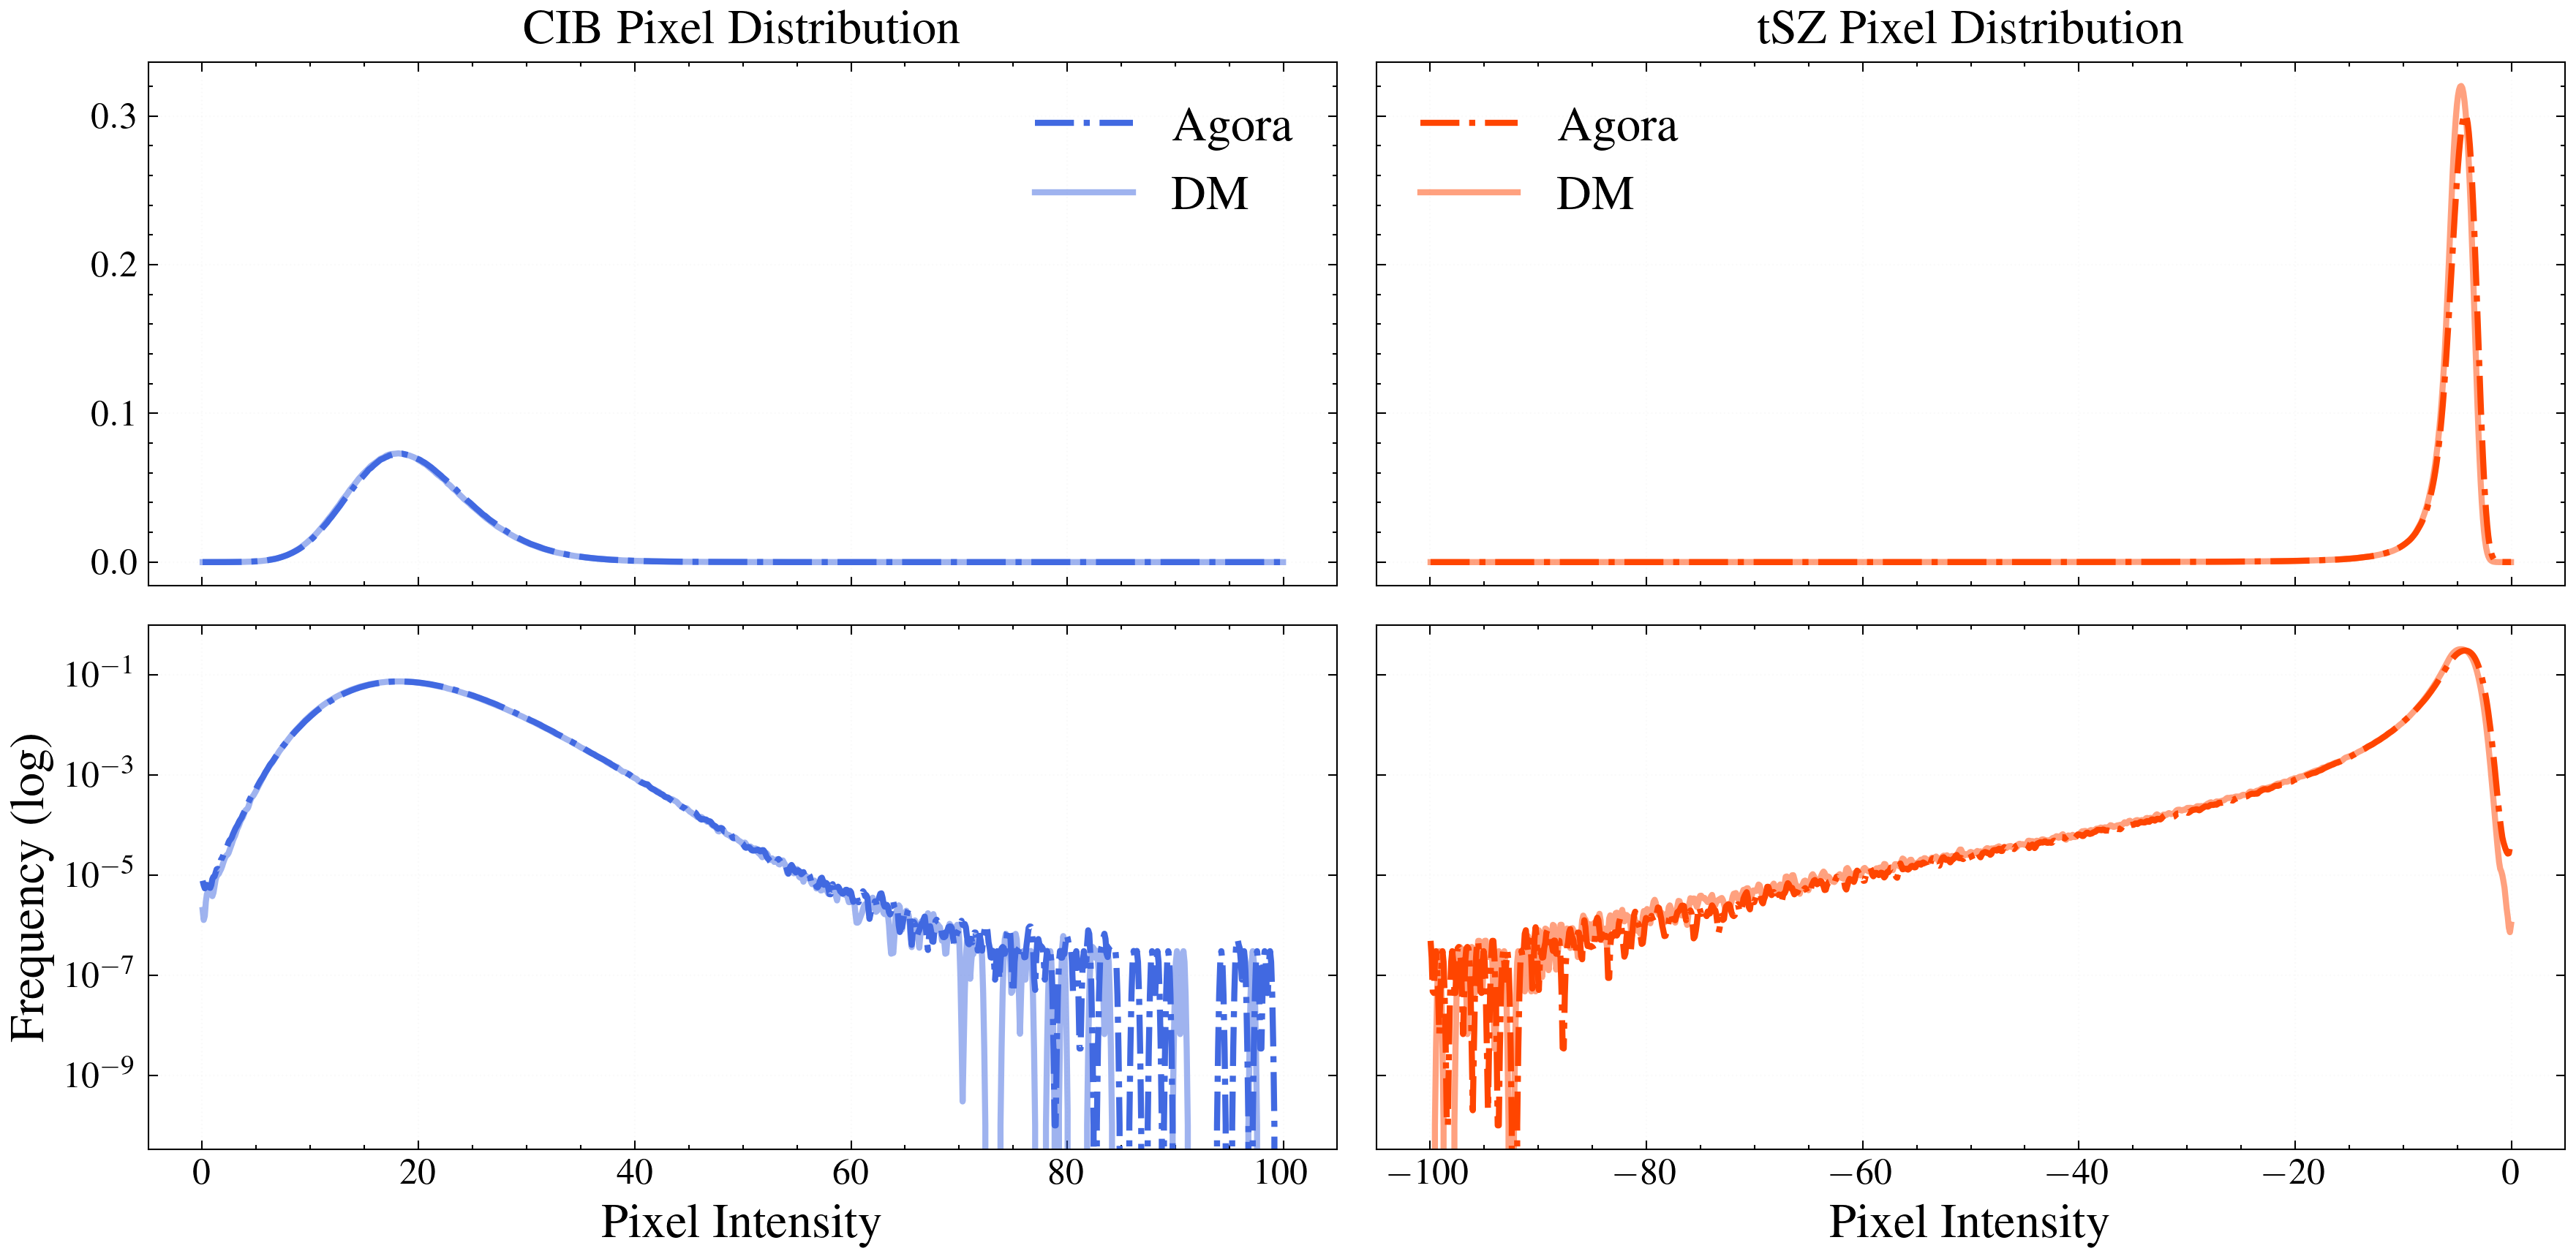

In [127]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

# Flatten channels
pixels_training_cib = training_images[:n_training_samples, :, :, 0].flatten()
pixels_training_tsz = training_images[:n_training_samples, :, :, 1].flatten()
pixels_samples_cib = all_samples[:n_training_samples, :,:,0].flatten()
pixels_samples_tsz = all_samples[:n_training_samples, :,:,1].flatten()

# Define bins
bins_cib = np.linspace(0, 100, 1000)
bins_tsz = np.linspace(-100, 0, 1000)

def smooth_hist(pixels, bins):
    hist, _ = np.histogram(pixels, bins=bins, density=True)
    return gaussian_filter1d(hist, sigma=1)

# Compute histograms
bin_centers_cib = (bins_cib[:-1] + bins_cib[1:]) / 2
train_hist_cib = smooth_hist(pixels_training_cib, bins_cib)
gen_hist_cib   = smooth_hist(pixels_samples_cib, bins_cib)

bin_centers_tsz = (bins_tsz[:-1] + bins_tsz[1:]) / 2
train_hist_tsz = smooth_hist(pixels_training_tsz, bins_tsz)
gen_hist_tsz   = smooth_hist(pixels_samples_tsz, bins_tsz)

# Create side-by-side plots
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex='col', sharey='row')
fig.subplots_adjust(wspace=0.15, hspace=0.1)

# --- Top row: linear scale ---
axs[0, 0].plot(bin_centers_cib, train_hist_cib, color='royalblue', lw=2, label='Agora', linestyle="-.")
axs[0, 0].plot(bin_centers_cib, gen_hist_cib, color='royalblue', lw=2, label='DM',alpha=0.5)
axs[0, 0].set_title("CIB Pixel Distribution", fontsize=16)
axs[0, 0].legend(fontsize=16)
axs[0, 0].grid(True, ls=':', lw=0.5)

axs[0, 1].plot(bin_centers_tsz, train_hist_tsz, color='orangered', lw=2, label='Agora', linestyle="-.")
axs[0, 1].plot(bin_centers_tsz, gen_hist_tsz, color='orangered', lw=2, label='DM',alpha=0.5)
axs[0, 1].set_title("tSZ Pixel Distribution", fontsize=16)
axs[0, 1].legend(fontsize=16)
axs[0, 1].grid(True, ls=':', lw=0.5)

# --- Bottom row: log scale ---
axs[1, 0].plot(bin_centers_cib, train_hist_cib, color='royalblue', lw=2, linestyle="-.")
axs[1, 0].plot(bin_centers_cib, gen_hist_cib, color='royalblue', lw=2,alpha=0.5)
axs[1, 0].set_yscale('log')
axs[1, 0].set_xlabel("Pixel Intensity", fontsize=16)
axs[1, 0].set_ylabel("Frequency (log)", fontsize=16)
axs[1, 0].grid(True, ls=':', lw=0.5)

axs[1, 1].plot(bin_centers_tsz, train_hist_tsz, color='orangered', lw=2, linestyle="-.")
axs[1, 1].plot(bin_centers_tsz, gen_hist_tsz, color='orangered', lw=2,alpha=0.5)
axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel("Pixel Intensity", fontsize=16)
axs[1, 1].grid(True, ls=':', lw=0.5)

# Clean x-tick labels on top row
for ax in axs[0]:
    ax.tick_params(labelbottom=False)

plt.tight_layout()
plt.savefig("figures/histogram_comparison_curve_2panel.pdf", dpi=200, bbox_inches="tight")
plt.savefig("figures/histogram_comparison_curve_2panel.png", dpi=200, bbox_inches="tight")
plt.show()

# Correlation visualisation

In [7]:
fpath_cib_95 = f"data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0_deg_2mJy_lp_CIB95.npy"
fpath_cib_150 = f"data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0_deg_2mJy_lp_CIB150.npy"
fpath_cib_857 = f"data/low_pass/2mJy/cut_maps_RES_256_ANG_X_6.0_deg_2mJy_lp_CIB857.npy"

cib_maps_95 = np.load(fpath_cib_95)
cib_maps_150 = np.load(fpath_cib_150)
cib_maps_857 = np.load(fpath_cib_857)

cut_maps = np.concatenate([cib_maps_95, cib_maps_150, cib_maps_857], axis=-1)

In [8]:
all_samples = np.load("data/low_pass/2mJy/new_samples_14_cib_2mJy_zero_6x6_w_au_lp_three.npy")

In [9]:
all_samples[:,0,] *= np.max(cut_maps[:,:,:,0])
all_samples[:,0,] = ((all_samples[:,0,] - np.mean(all_samples[:,0,]))*(np.std(cut_maps[:,:,:,0,])/np.std(all_samples[:,0,]))) + np.mean(all_samples[:,0,])
all_samples[:,1,] *= np.max(cut_maps[:,:,:,1])
all_samples[:,1,] = ((all_samples[:,1,] - np.mean(all_samples[:,1,]))*(np.std(cut_maps[:,:,:,1,])/np.std(all_samples[:,1,]))) + np.mean(all_samples[:,1,])
all_samples[:,2,] *= np.max(cut_maps[:,:,:,2])
all_samples[:,2,] = ((all_samples[:,2,] - np.mean(all_samples[:,2,]))*(np.std(cut_maps[:,:,:,2,])/np.std(all_samples[:,2,]))) + np.mean(all_samples[:,2,])

In [10]:
diffusion_maps = all_samples.transpose(0, 2, 3, 1)

In [22]:
np.min(cut_maps[:,:,:,2]),np.max(cut_maps[:,:,:,2])

(np.float32(0.0), np.float32(2704532.5))

In [23]:
np.min(diffusion_maps[:,:,:,2]),np.max(diffusion_maps[:,:,:,2])

(np.float32(-23480.188), np.float32(2420757.2))

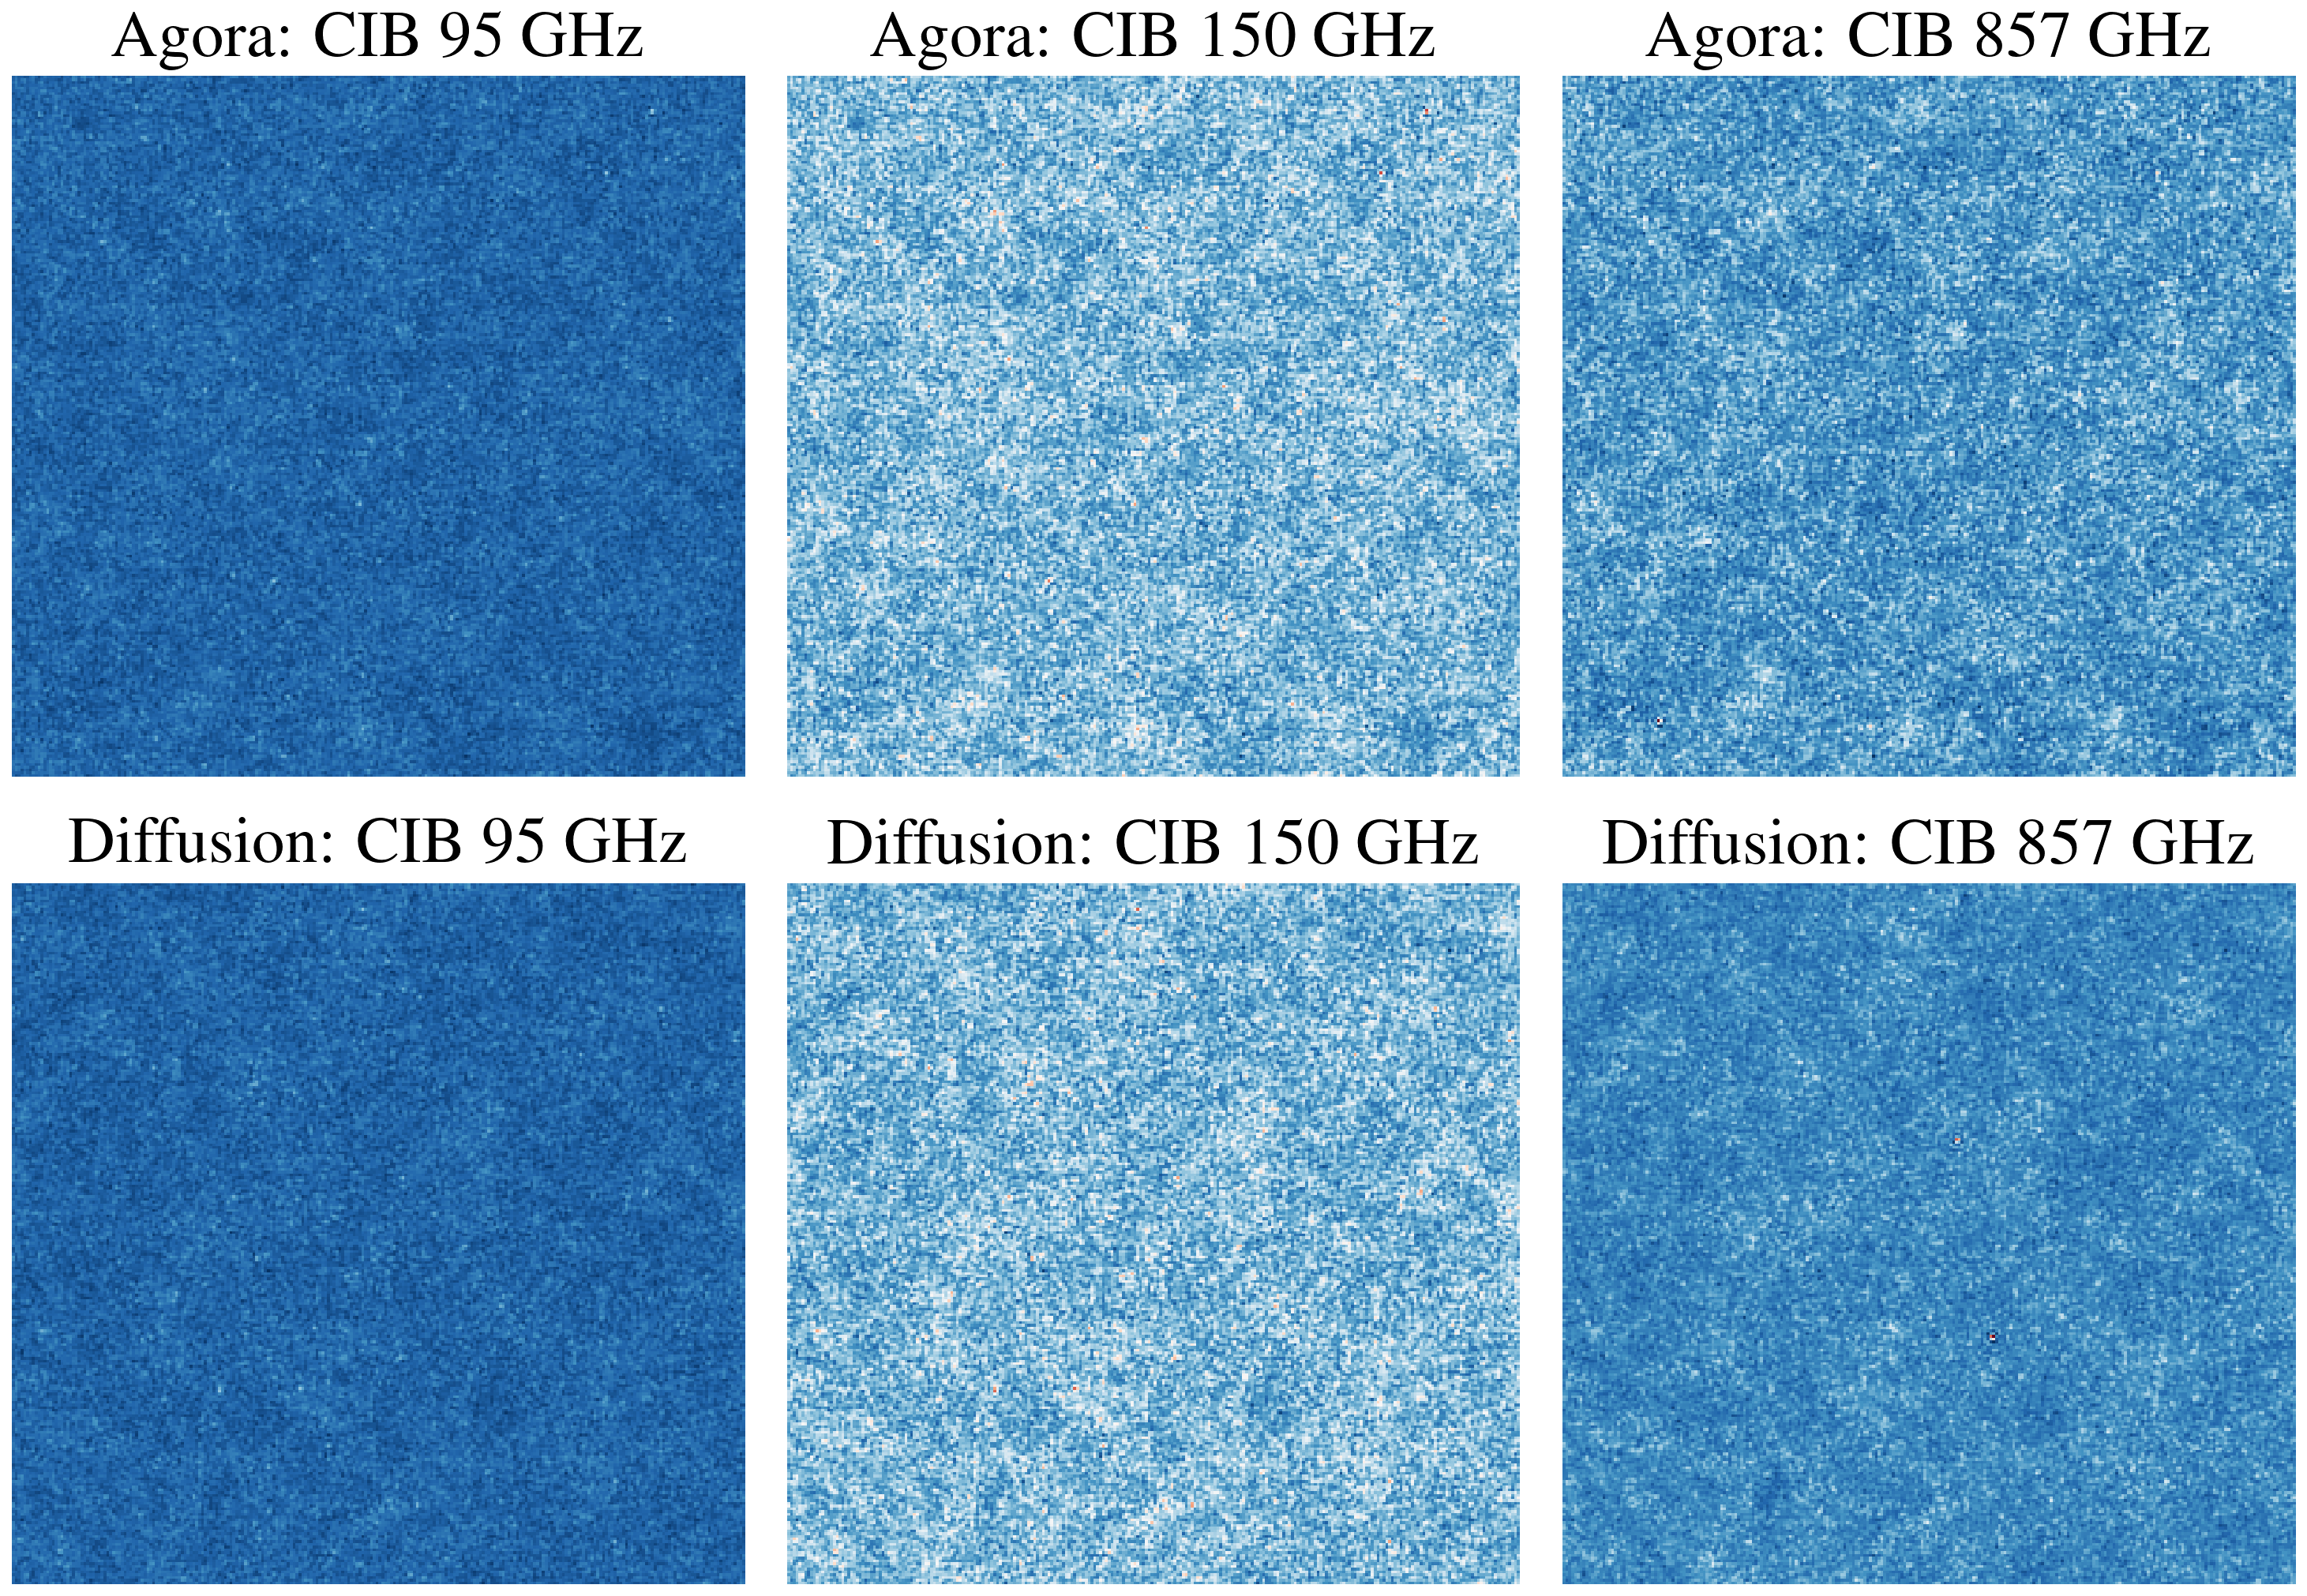

In [200]:
example_idx=100
example_agora = cut_maps[example_idx]
example_diffusion = diffusion_maps[example_idx]

fig1, axs = plt.subplots(2, 3, figsize=(10, 7))
plt.subplots_adjust(wspace=0.01)
titles = ["CIB 95 GHz", "CIB 150 GHz", "CIB 857 GHz"]

vmin_vmax_dic = {0: [0, 70], 1: [0, 70], 2: [None, None]}

sp_i = 1
for i in range(3):
    ax = plt.subplot(2,3,sp_i)
    vmin, vmax = vmin_vmax_dic[i]
    plt.imshow(example_agora[:, :, i], cmap='RdBu_r',aspect="auto",vmin = vmin, vmax = vmax)
    #plt.colorbar()
    ax.set_title(f"Agora: {titles[i]}", fontsize=20)
    plt.axis('off')
    sp_i+=1
for i in range(3):
    ax = plt.subplot(2,3,sp_i)
    vmin, vmax = vmin_vmax_dic[i]
    plt.imshow(example_diffusion[:, :, i], cmap='RdBu_r',aspect="auto",vmin = vmin, vmax = vmax)
    #plt.colorbar()
    ax.set_title(f"Diffusion: {titles[i]}", fontsize=20)
    plt.axis('off')
    sp_i+=1

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.tight_layout()
#plt.savefig("figures/example_cib_triplet.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("figures/example_cib_triplet.png", dpi=200, bbox_inches="tight")
plt.show()

/global/u2/k/kp22/ddpm_paper/ps_utils.py:253: ComplexWarning: Casting complex values to real discards the imaginary part
  radprf[b,1]=np.sum(z[ind])/hits


In [133]:
n_samples = 200
import random
idxs = random.sample(range(diffusion_maps.shape[0]), n_samples)

cls_auto_95, cls_auto_150, cls_auto_857 = [], [], []
cls_cross_95_150, cls_cross_95_857, cls_cross_150_857 = [], [], []

for i in idxs:
    m95, m150, m857 = cut_maps[i, :, :, 0], cut_maps[i, :, :, 1], cut_maps[i, :, :, 2]
    ell, cl_95 = map2cl(flatskymapparams, m95)
    _, cl_150 = map2cl(flatskymapparams, m150)
    _, cl_857 = map2cl(flatskymapparams, m857)
    _, cl_95_150 = map2cl(flatskymapparams, m95, m150)
    _, cl_95_857 = map2cl(flatskymapparams, m95, m857)
    _, cl_150_857 = map2cl(flatskymapparams, m150, m857)

    cls_auto_95.append(cl_95)
    cls_auto_150.append(cl_150)
    cls_auto_857.append(cl_857)
    cls_cross_95_150.append(cl_95_150)
    cls_cross_95_857.append(cl_95_857)
    cls_cross_150_857.append(cl_150_857)

mean_cl_95 = np.mean(cls_auto_95, axis=0)
mean_cl_150 = np.mean(cls_auto_150, axis=0)
mean_cl_857 = np.mean(cls_auto_857, axis=0)
mean_cl_95_150 = np.mean(cls_cross_95_150, axis=0)
mean_cl_95_857 = np.mean(cls_cross_95_857, axis=0)
mean_cl_150_857 = np.mean(cls_cross_150_857, axis=0)

cls_dm_95, cls_dm_150, cls_dm_857 = [], [], []
cls_dm_95_150, cls_dm_95_857, cls_dm_150_857 = [], [], []

for i in idxs:
    m95, m150, m857 = diffusion_maps[i, :, :, 0], diffusion_maps[i, :, :, 1], diffusion_maps[i, :, :, 2]
    _, cl_95 = map2cl(flatskymapparams, m95)
    _, cl_150 = map2cl(flatskymapparams, m150)
    _, cl_857 = map2cl(flatskymapparams, m857)
    _, cl_95_150 = map2cl(flatskymapparams, m95, m150)
    _, cl_95_857 = map2cl(flatskymapparams, m95, m857)
    _, cl_150_857 = map2cl(flatskymapparams, m150, m857)

    cls_dm_95.append(cl_95)
    cls_dm_150.append(cl_150)
    cls_dm_857.append(cl_857)
    cls_dm_95_150.append(cl_95_150)
    cls_dm_95_857.append(cl_95_857)
    cls_dm_150_857.append(cl_150_857)

# Compute means
mean_dm_95 = np.mean(cls_dm_95, axis=0)
mean_dm_150 = np.mean(cls_dm_150, axis=0)
mean_dm_857 = np.mean(cls_dm_857, axis=0)
mean_dm_95_150 = np.mean(cls_dm_95_150, axis=0)
mean_dm_95_857 = np.mean(cls_dm_95_857, axis=0)
mean_dm_150_857 = np.mean(cls_dm_150_857, axis=0)

/global/u2/k/kp22/ddpm_paper/ps_utils.py:254: ComplexWarning: Casting complex values to real discards the imaginary part
  radprf[b,1]=np.sum(z[ind])/hits


<Figure size 1920x1440 with 0 Axes>

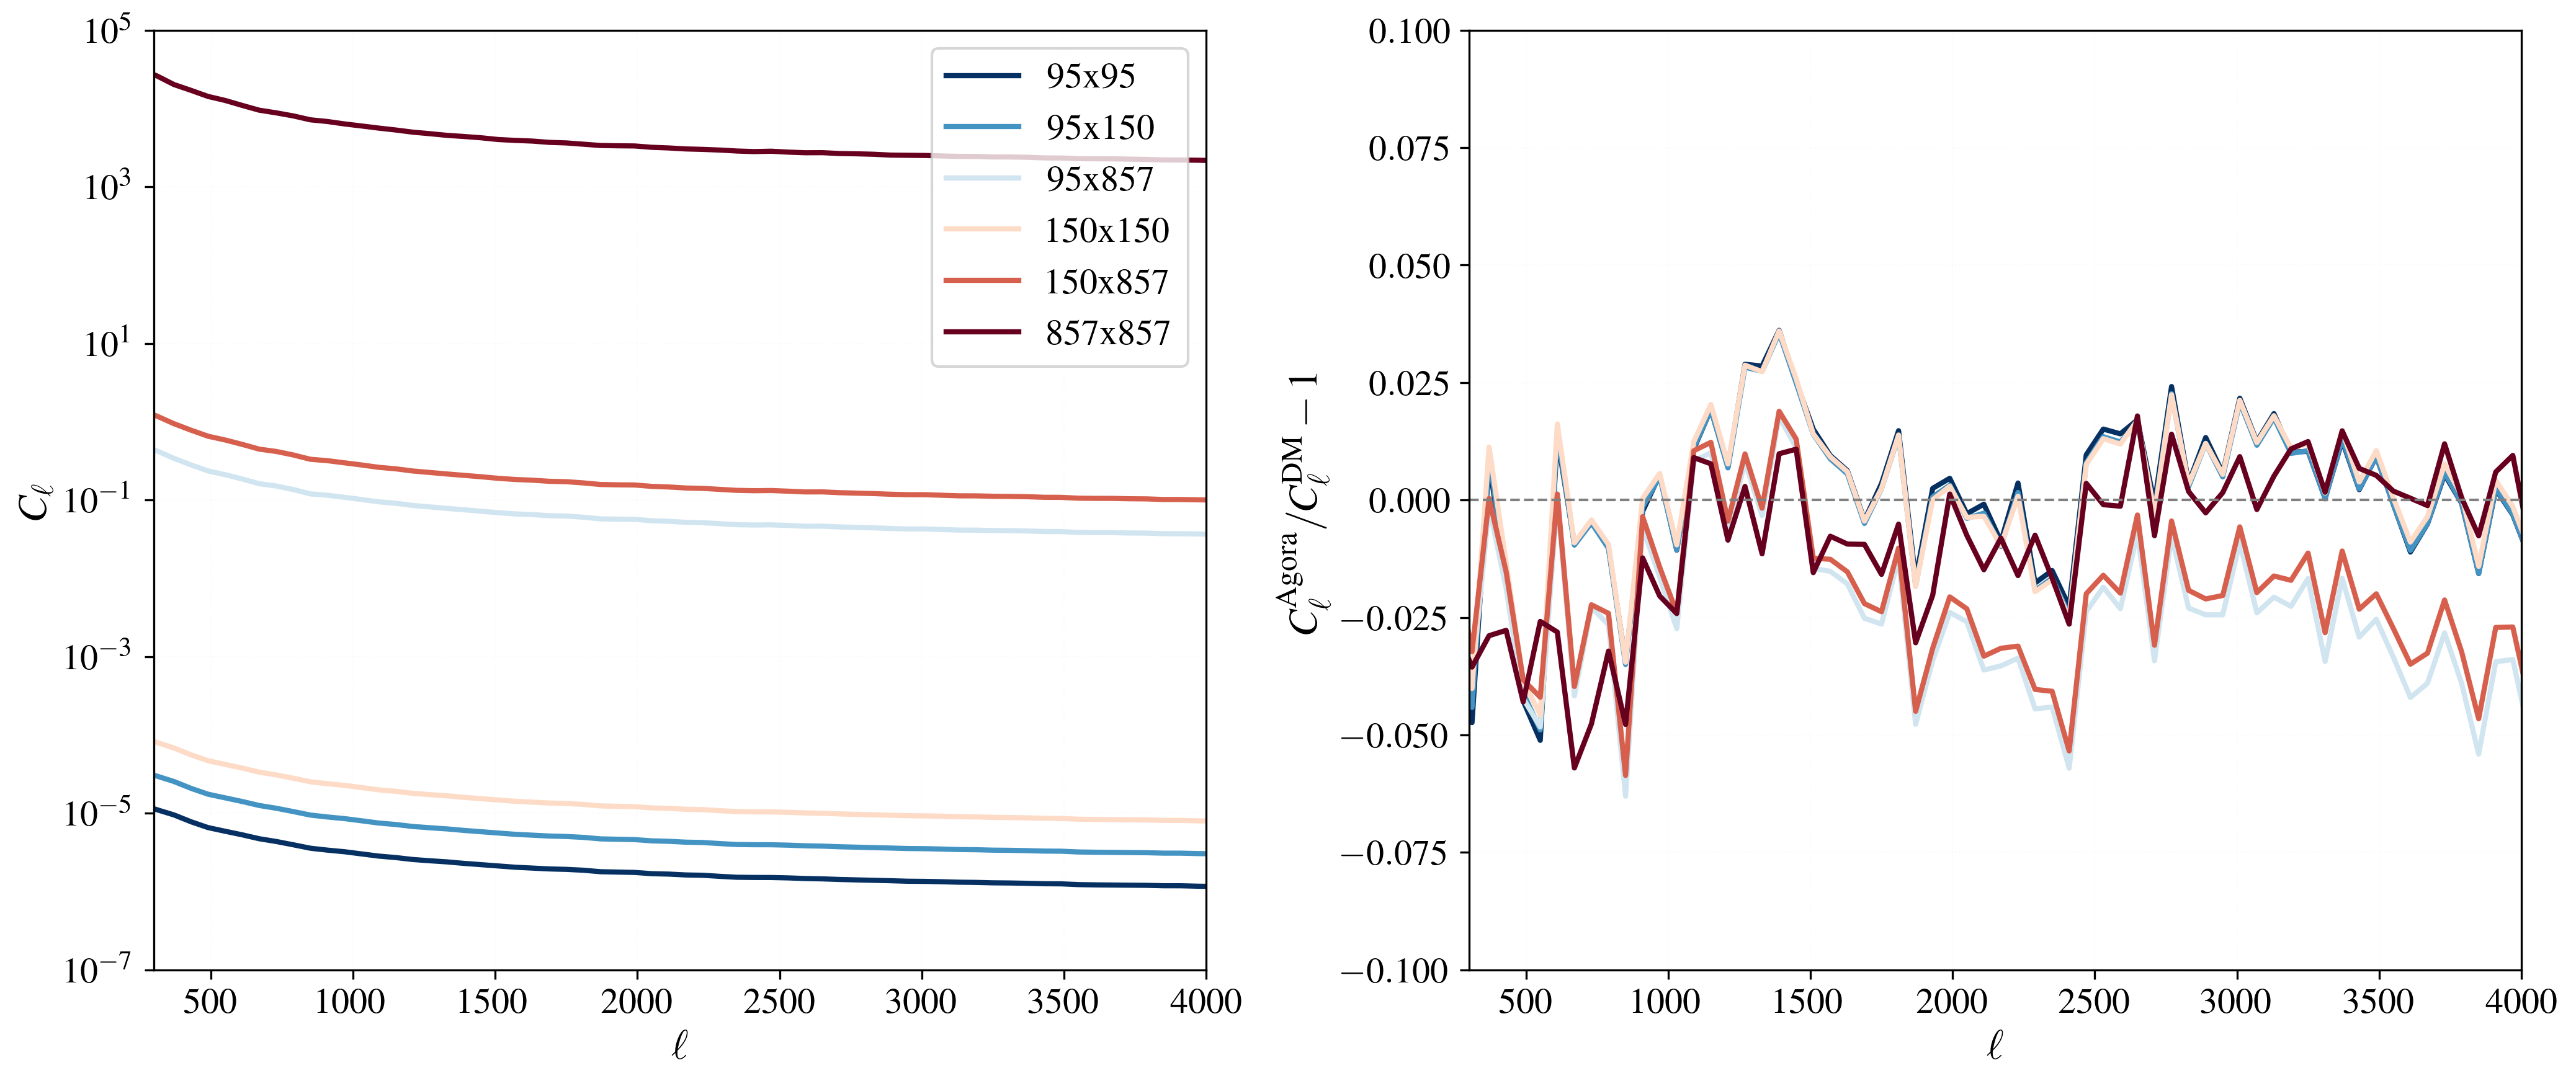

In [29]:
from pylab import *
from matplotlib import colormaps as cm

ordered_labels = [
    ("95x95", mean_auto_cls_train[0], mean_auto_cls_dm[0]),
    ("95x150", mean_cross_cls_train[(0,1)], mean_cross_cls_dm[(0,1)]),
    ("95x857", mean_cross_cls_train[(0,2)], mean_cross_cls_dm[(0,2)]),
    ("150x150", mean_auto_cls_train[1], mean_auto_cls_dm[1]),
    ("150x857", mean_cross_cls_train[(1,2)], mean_cross_cls_dm[(1,2)]),
    ("857x857", mean_auto_cls_train[2], mean_auto_cls_dm[2]),
]

cmap = cm['RdBu_r'].resampled(len(ordered_labels))
colors = [cmap(i) for i in range(len(ordered_labels))]

clf()
fig = figure(figsize=(14, 6))

# Subplot 1: Power spectra
subplot(1, 2, 1)
for i, (label, cl_agora, _) in enumerate(ordered_labels):
    plot(ell, cl_agora, label=label, lw=2, color=colors[i])
yscale('log')
xlabel(r"$\ell$", fontsize=16)
ylabel(r"$C_\ell$", fontsize=16)
xlim(300,4000)
ylim(1e-7, 1e5)
xticks(fontsize=14)
yticks(fontsize=14)
grid(True, which='both', ls=':', lw=0.5)
legend(fontsize=14)

# Subplot 2: Ratio
subplot(1, 2, 2)
for i, (label, cl_agora, cl_dm) in enumerate(ordered_labels):
    plot(ell, (cl_agora / cl_dm) - 1, label=label, lw=2, color=colors[i])
axhline(0.0, color='gray', linestyle='--', lw=1)
xlabel(r"$\ell$", fontsize=16)
ylabel(r"$C_\ell^{\mathrm{Agora}}/C_\ell^{\mathrm{DM}} - 1$", fontsize=16)
ylim(-0.1, 0.1)
xlim(300, 4000)
xticks(fontsize=14)
yticks(fontsize=14)
grid(True, which='both', ls=':', lw=0.5)

tight_layout()
#savefig("figures/example_cib_triplet_power_spectra.pdf", dpi=200, bbox_inches="tight")
#savefig("figures/example_cib_triplet_power_spectra.png", dpi=200, bbox_inches="tight")
show()


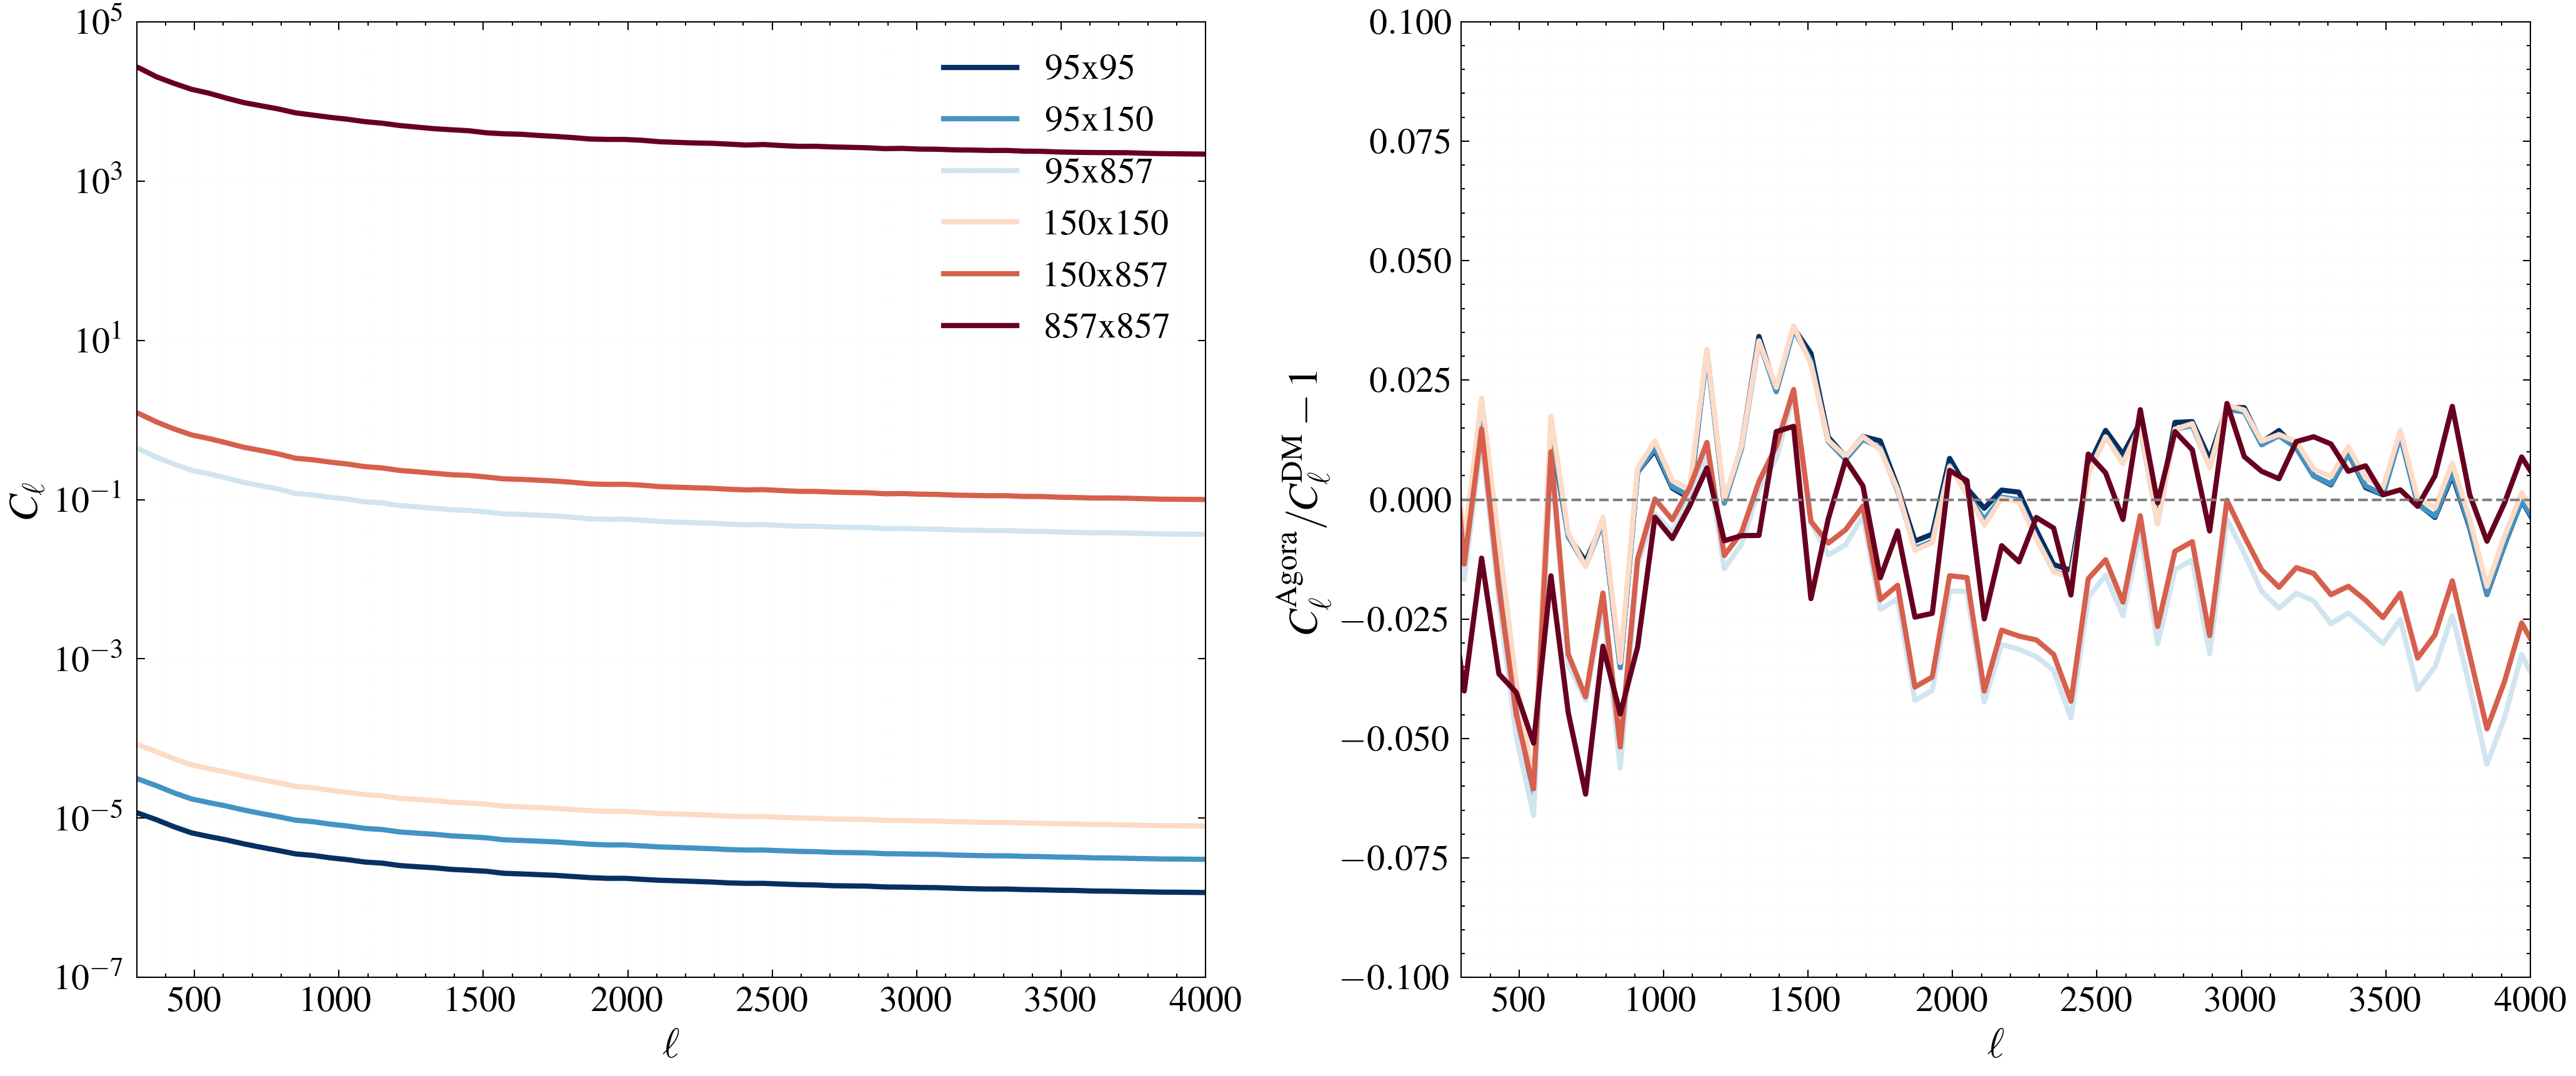

In [143]:
from matplotlib import colormaps as cm
import matplotlib.colors as mcolors

ordered_labels = [
    ("95x95", mean_cl_95, mean_dm_95),
    ("95x150", mean_cl_95_150, mean_dm_95_150),
    ("95x857", mean_cl_95_857, mean_dm_95_857),
    ("150x150", mean_cl_150, mean_dm_150),
    ("150x857", mean_cl_150_857, mean_dm_150_857),
    ("857x857", mean_cl_857, mean_dm_857),
]
cmap = cm['RdBu_r'].resampled(len(ordered_labels))
#cmap = cm.get_cmap("RdBu_r", len(ordered_labels))
colors = [cmap(i) for i in range(len(ordered_labels))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for i, (label, cl_agora, _) in enumerate(ordered_labels):
    ax1.plot(ell, cl_agora, label=label, lw=2, color=colors[i])
ax1.set_yscale('log')
ax1.set_xlabel(r"$\ell$", fontsize=16)
ax1.set_ylabel(r"$C_\ell$", fontsize=16)
ax1.set_ylim(1e-7, 1e5)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
#ax1.set_title("Agora Power Spectra")
ax1.grid(True, which='both', ls=':', lw=0.5)
ax1.legend(fontsize=14)

for i, (label, cl_agora, cl_dm) in enumerate(ordered_labels):
    ax2.plot(ell, (cl_agora / cl_dm) - 1, label=label, lw=2, color=colors[i])
ax2.axhline(0.0, color='gray', linestyle='--', lw=1)
ax2.set_xlabel(r"$\ell$", fontsize=16)
ax2.set_ylabel(r"$C_\ell^{\mathrm{Agora}}/C_\ell^{\mathrm{DM}} - 1$", fontsize=16)
ax2.set_ylim(-0.1, 0.1)
ax2.set_xlim(300, 4000)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
#ax2.set_title("Power Spectrum Ratio")
ax2.grid(True, which='both', ls=':', lw=0.5)

plt.tight_layout()
#plt.savefig("figures/example_cib_triplet_power_spectra.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("figures/example_cib_triplet_power_spectra.png", dpi=200, bbox_inches="tight")
plt.show()

<Figure size 1920x1440 with 0 Axes>

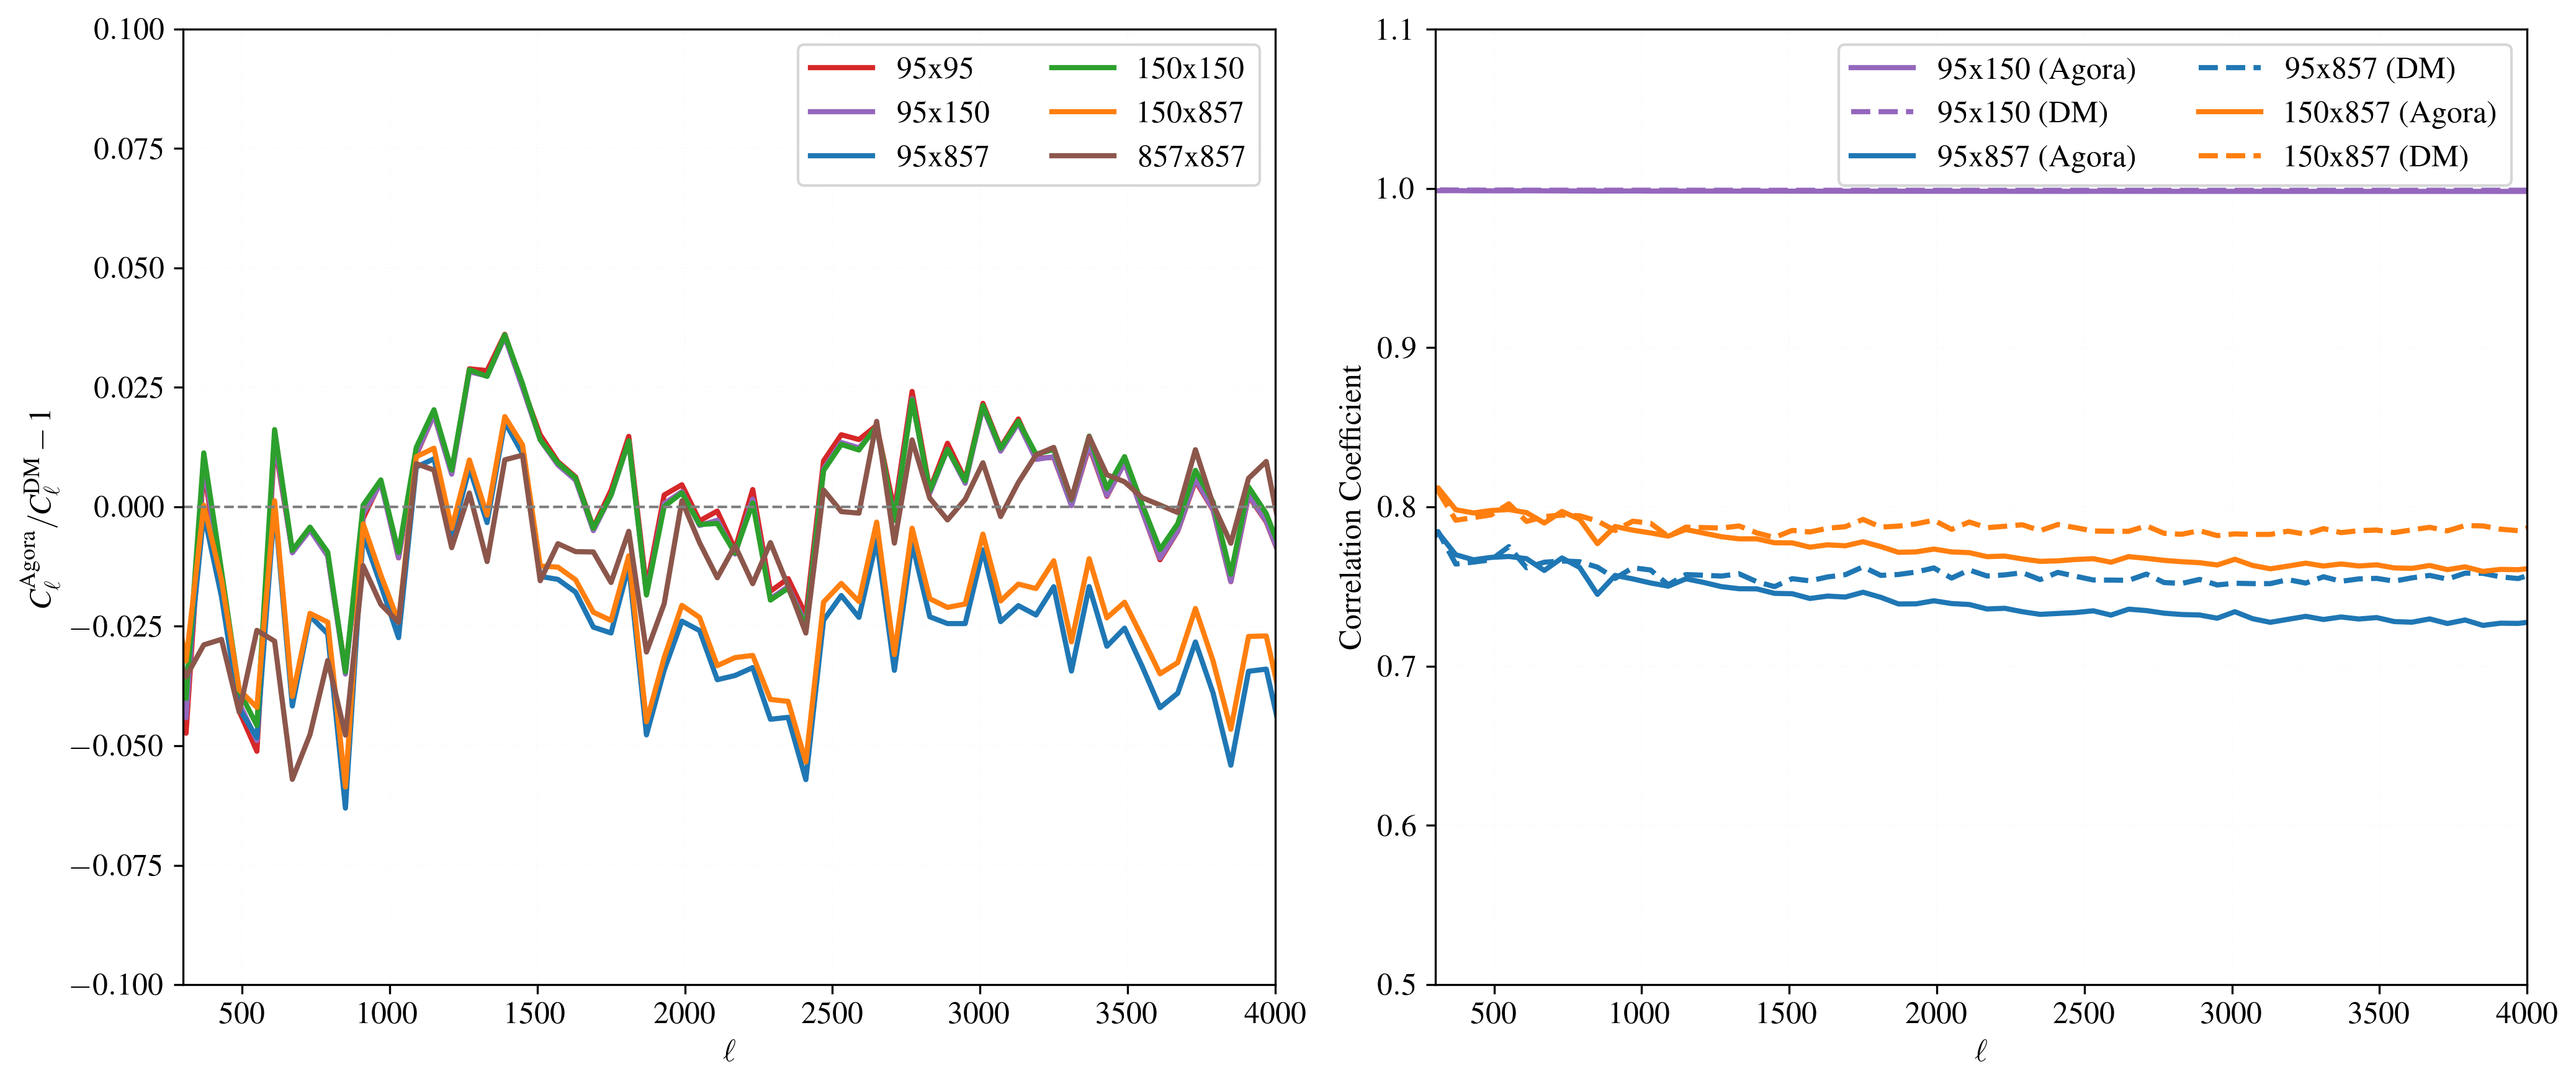

In [30]:
from pylab import *

def correlation_coeff(cross, auto1, auto2):
    return np.array(cross) / np.sqrt(np.array(auto1) * np.array(auto2))

pairs = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
labels = ["95x95", "95x150", "95x857", "150x150", "150x857", "857x857"]
colors = ['tab:red', 'tab:purple', 'tab:blue', 'tab:green', 'tab:orange', 'tab:brown']

clf()
figure(figsize=(14, 6))

# Left plot: ratio of C_ell
subplot(1, 2, 1)
for (i, (ch1, ch2)) in enumerate(pairs):
    if ch1 == ch2:
        cl_train = mean_auto_cls_train[ch1]
        cl_dm = mean_auto_cls_dm[ch1]
    else:
        cl_train = mean_cross_cls_train[(ch1, ch2)]
        cl_dm = mean_cross_cls_dm[(ch1, ch2)]

    plot(ell, (cl_train / cl_dm) - 1, label=labels[i], lw=2, color=colors[i])
axhline(0, color='gray', ls='--', lw=1)
xlabel(r"$\ell$")
ylabel(r"$C_\ell^{\mathrm{Agora}} / C_\ell^{\mathrm{DM}} - 1$")
xlim(300, 4000)
ylim(-0.1, 0.1)
grid(True, which='both', ls=':', lw=0.5)
legend(fontsize=12, ncol=2)

# Right plot: correlation coefficient
subplot(1, 2, 2)
for (i, (ch1, ch2)) in enumerate(pairs):
    if ch1 == ch2:
        continue  # skip auto for correlation coefficient
    cc_train = correlation_coeff(cross_cls_train[(ch1, ch2)],
                                 auto_cls_train[ch1],
                                 auto_cls_train[ch2])
    cc_dm = correlation_coeff(cross_cls_dm[(ch1, ch2)],
                              auto_cls_dm[ch1],
                              auto_cls_dm[ch2])

    mean_cc_train = np.mean(cc_train, axis=0)
    mean_cc_dm = np.mean(cc_dm, axis=0)

    plot(ell, mean_cc_train, label=f"{labels[i]} (Agora)", color=colors[i], lw=2)
    plot(ell, mean_cc_dm, label=f"{labels[i]} (DM)", color=colors[i], lw=2, ls='--')

xlabel(r"$\ell$")
ylabel("Correlation Coefficient")
xlim(300, 4000)
ylim(0.5, 1.1)
grid(True, which='both', ls=':', lw=0.5)
legend(ncol=2, fontsize=12)

tight_layout()
#savefig("figures/cib_triplet_power_ratio_and_corr.pdf", dpi=200, bbox_inches="tight")
#savefig("figures/cib_triplet_power_ratio_and_corr.png", dpi=200, bbox_inches="tight")
show()


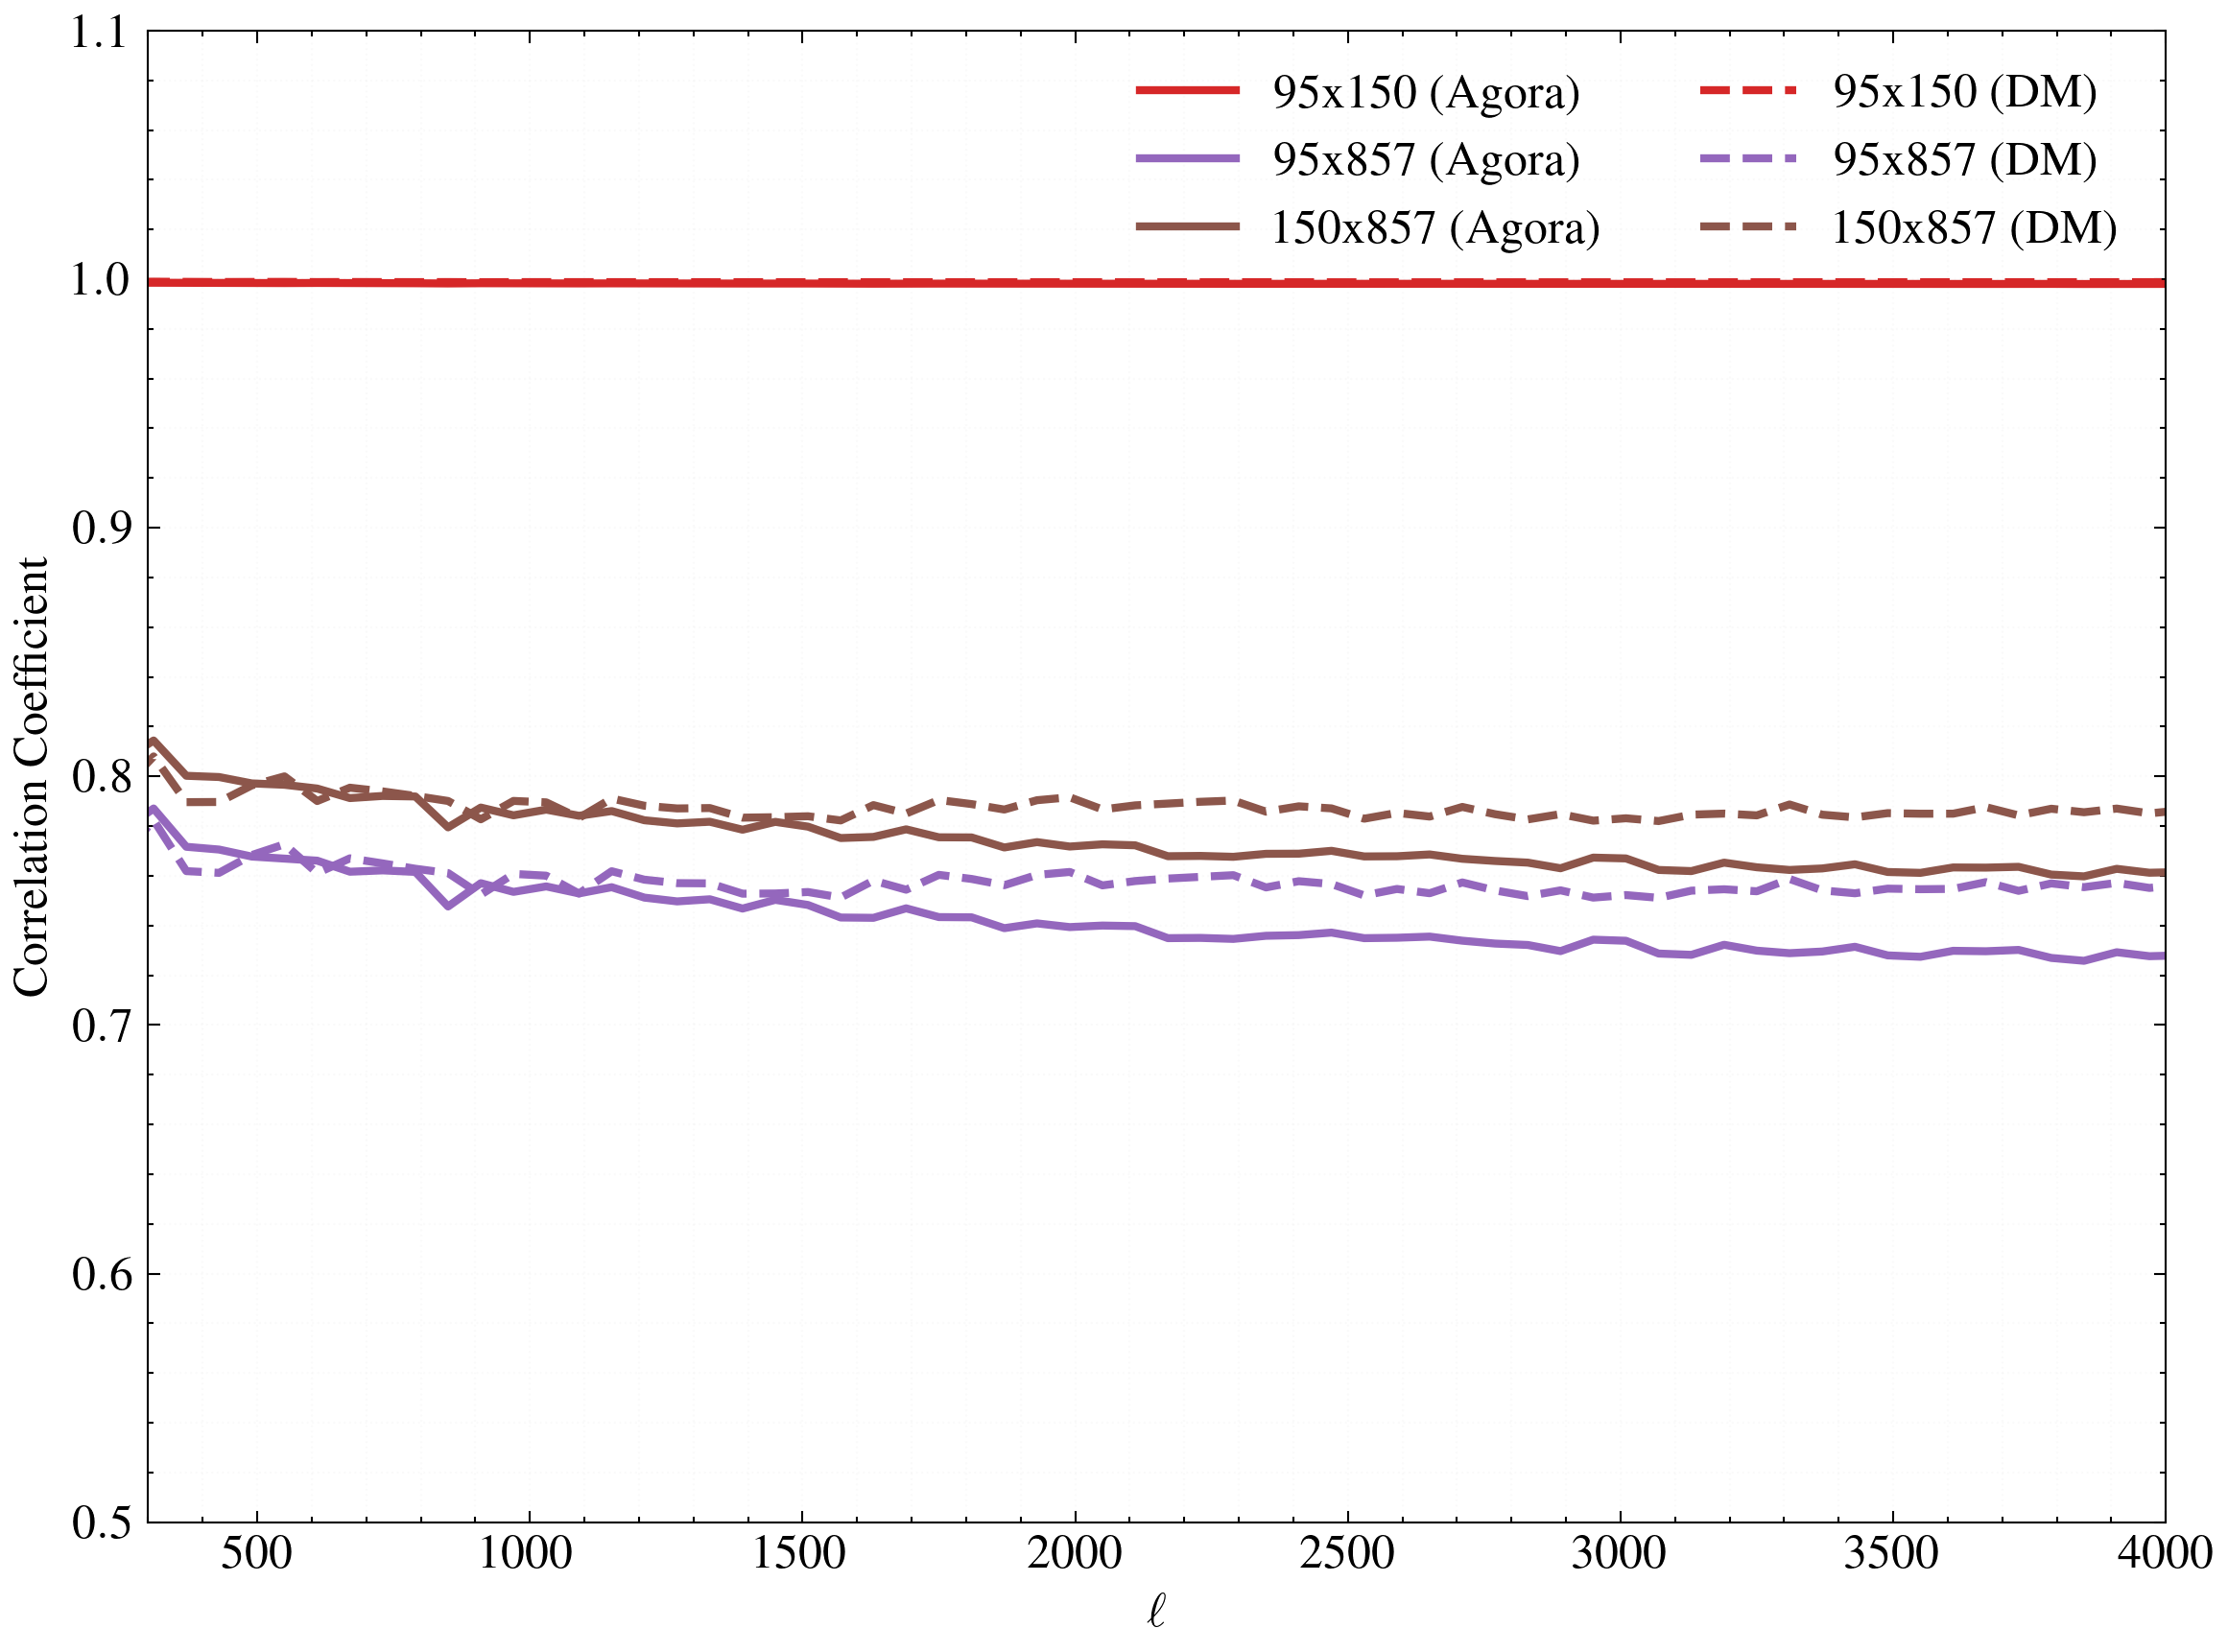

In [311]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ell, corr_agora_95_150, label="95x150 (Agora)", color='tab:red', lw=2)
ax.plot(ell, corr_agora_95_857, label="95x857 (Agora)", color='tab:purple', lw=2)
ax.plot(ell, corr_agora_150_857, label="150x857 (Agora)", color='tab:brown', lw=2)

ax.plot(ell, corr_dm_95_150, label="95x150 (DM)", color='tab:red', lw=2, linestyle='--')
ax.plot(ell, corr_dm_95_857, label="95x857 (DM)", color='tab:purple', lw=2, linestyle='--')
ax.plot(ell, corr_dm_150_857, label="150x857 (DM)", color='tab:brown', lw=2, linestyle='--')

ax.set_xlabel(r"$\ell$")
ax.set_ylabel("Correlation Coefficient")
ax.set_ylim(0.5, 1.1)
ax.set_xlim(300,4000)
ax.grid(True, which='both', ls=':', lw=0.5)
ax.legend(ncol=2, fontsize=12)

plt.tight_layout()
#plt.savefig("figures/example_cib_triplet_correlation.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("figures/example_cib_triplet_correlation.png", dpi=200, bbox_inches="tight")

plt.show()